In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

loan_df = pd.read_csv("../Data/Loan_Default.csv")

loan_df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [2]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [62]:
loan_df.shape

(148670, 37)

In [57]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,148670.0,9.922450e+04,42917.476598,24890.000000,62057.250000,99224.500000,136391.750000,1.735590e+05
year,148670.0,2.019000e+03,0.000000,2019.000000,2019.000000,2019.000000,2019.000000,2.019000e+03
loan_amount,148670.0,3.311177e+05,183909.310127,16500.000000,196500.000000,296500.000000,436500.000000,3.576500e+06
rate_of_interest,112231.0,4.045476e+00,0.561391,0.000000,3.625000,3.990000,4.375000,8.000000e+00
Interest_rate_spread,112031.0,4.416557e-01,0.513043,-3.638000,0.076000,0.390400,0.775400,3.357000e+00
Upfront_charges,109028.0,3.224996e+03,3251.121510,0.000000,581.490000,2596.450000,4812.500000,6.000000e+04
term,148629.0,3.351366e+02,58.409084,96.000000,360.000000,360.000000,360.000000,3.600000e+02
property_value,133572.0,4.978935e+05,359935.315562,8000.000000,268000.000000,418000.000000,628000.000000,1.650800e+07
income,139520.0,6.957339e+03,6496.586382,0.000000,3720.000000,5760.000000,8520.000000,5.785800e+05
Credit_Score,148670.0,6.997891e+02,115.875857,500.000000,599.000000,699.000000,800.000000,9.000000e+02


## Defining A Target

In [3]:
loan_df["Status"].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

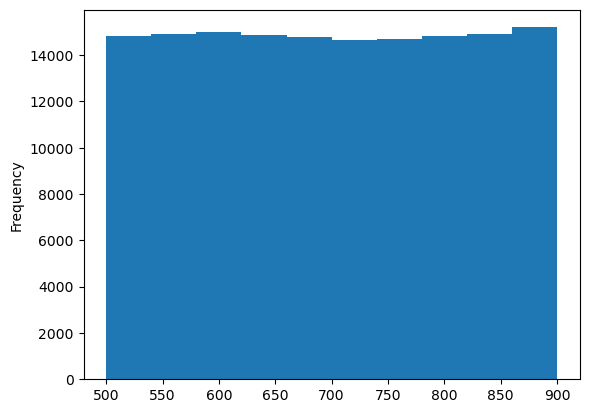

In [58]:
loan_df["Credit_Score"].plot.hist()

In [59]:
# numeric cutoff
loan_df["Fake_Target"] = np.where(loan_df["Credit_Score"] < 580, 1, 0)

loan_df["Fake_Target"].value_counts()

#loan_df.drop("Fake_Target", axis=1)

Fake_Target
0    118933
1     29737
Name: count, dtype: int64

In [6]:
loan_df["loan_type"].value_counts()

loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

In [65]:
# category mapping

loan_df["Fake_Target"] = (
    loan_df["loan_type"].map(
        {"type1": 0,
         "type2": 1,
         "type3": 1
        }
    )
)

loan_df["Fake_Target"].value_counts()

loan_df = loan_df.drop("Fake_Target", axis=1)

## Exploring The Target

In [64]:
loan_df["Status"].value_counts(normalize=True)

Status
0    0.753555
1    0.246445
Name: proportion, dtype: float64

<Axes: xlabel='Status'>

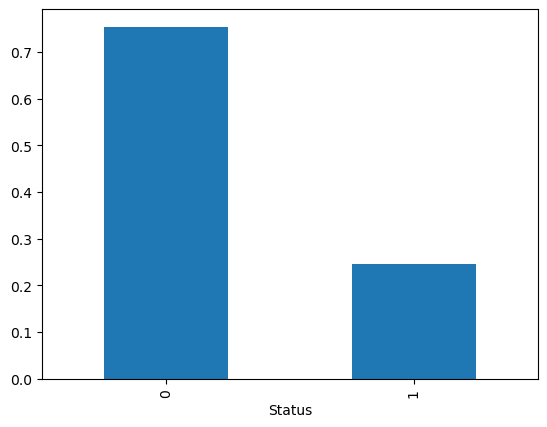

In [46]:
loan_df["Status"].value_counts(normalize=True).plot.bar()

## Exploring The Features

In [9]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [47]:
loan_df["Status"].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [48]:
loan_df["Status"].value_counts(normalize=True)

Status
0    0.753555
1    0.246445
Name: proportion, dtype: float64

<Axes: xlabel='Status'>

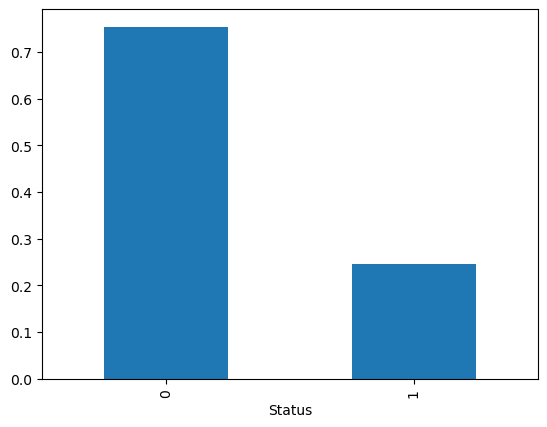

In [49]:
loan_df["Status"].value_counts(normalize=True).plot.bar()

<Axes: ylabel='Frequency'>

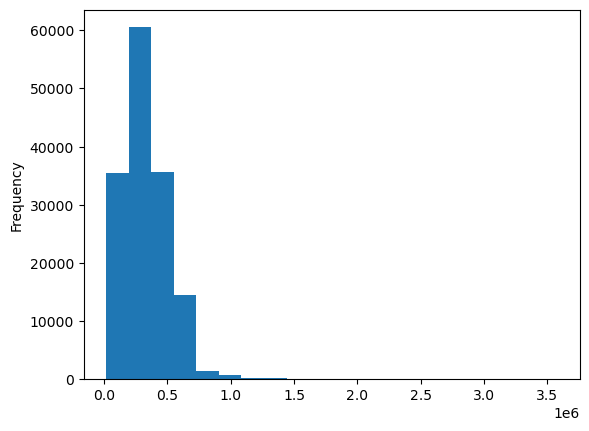

In [10]:
# numeric

loan_df["loan_amount"].plot.hist(bins=20)

<Axes: >

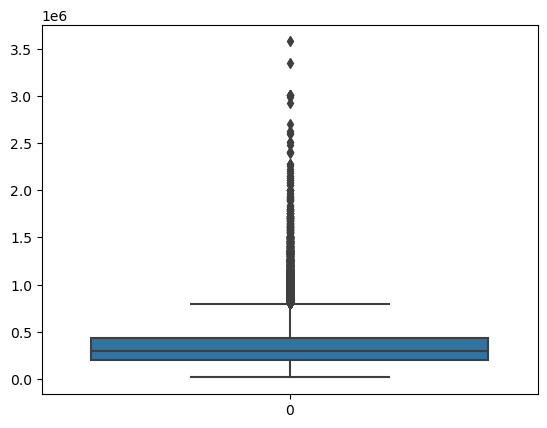

In [11]:
import seaborn as sns

sns.boxplot(loan_df["loan_amount"])

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

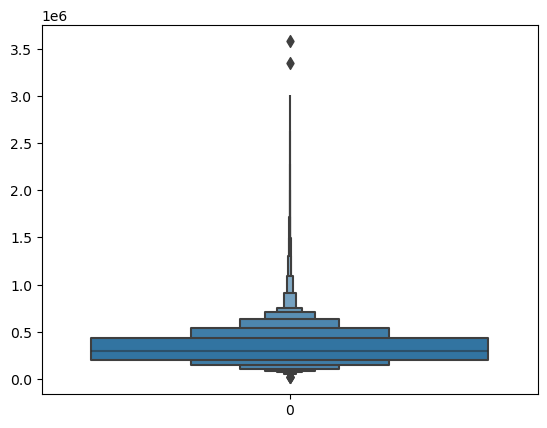

In [66]:
sns.boxenplot(loan_df["loan_amount"])

<Axes: >

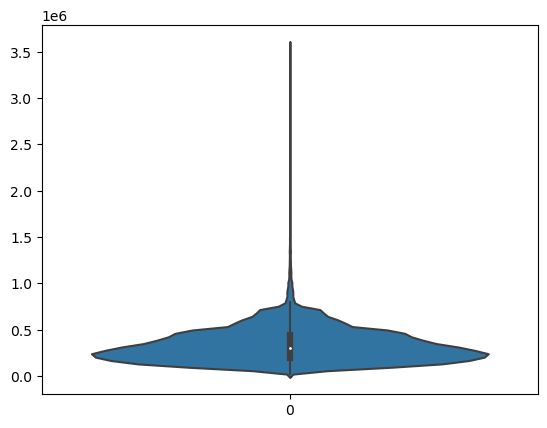

In [67]:
sns.violinplot(loan_df["loan_amount"])

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


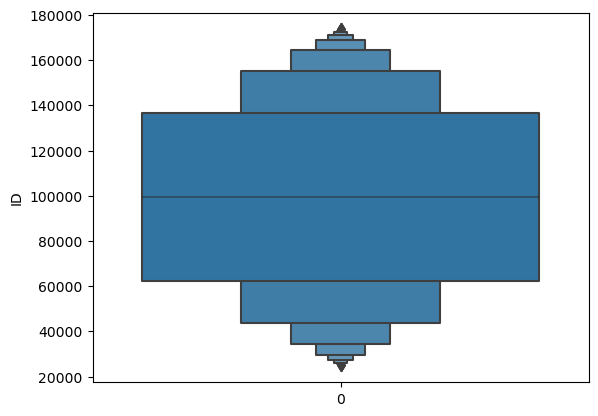

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


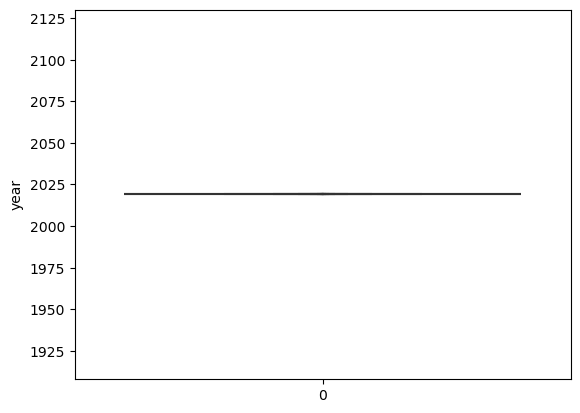

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


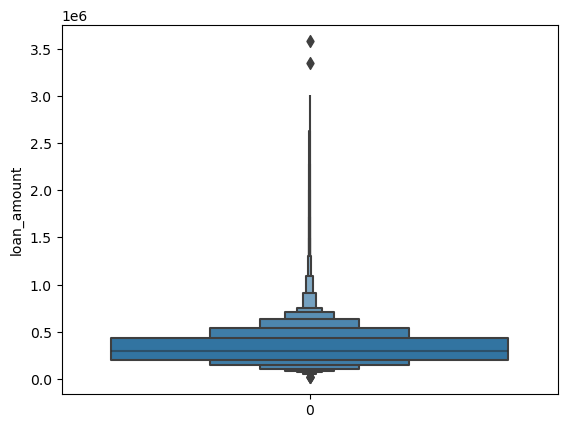

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


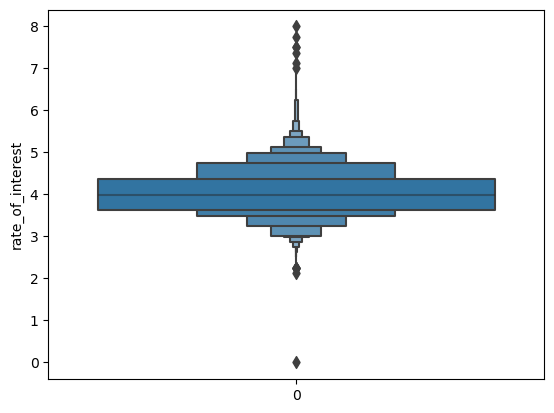

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


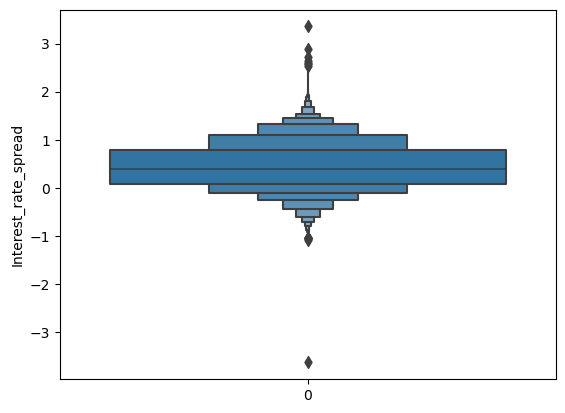

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


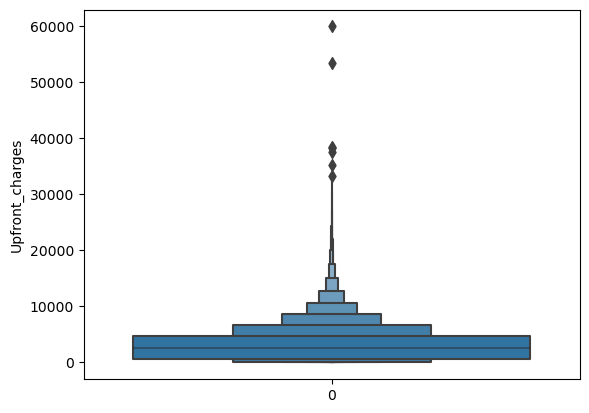

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


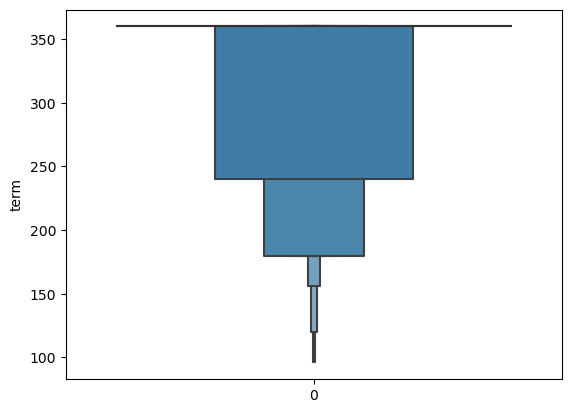

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


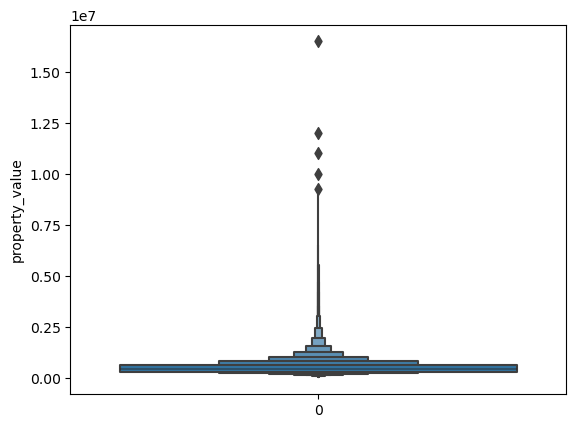

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


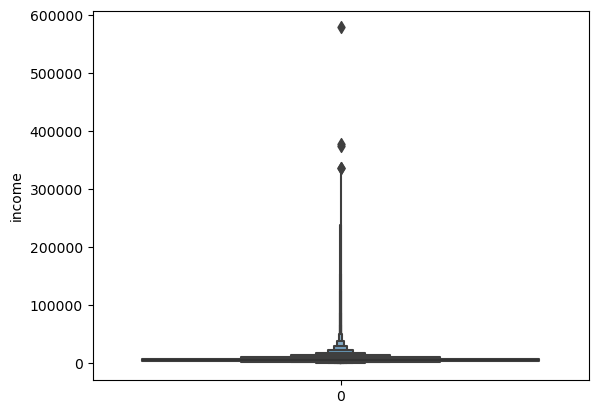

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


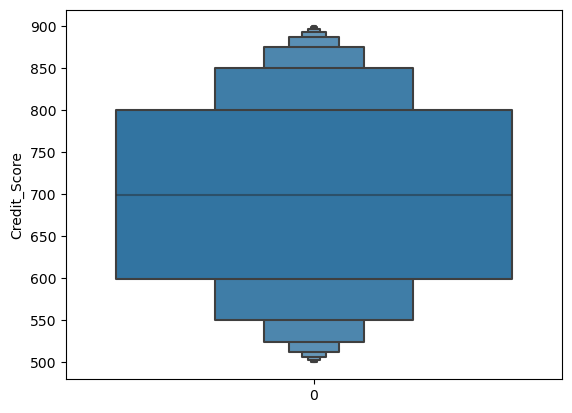

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


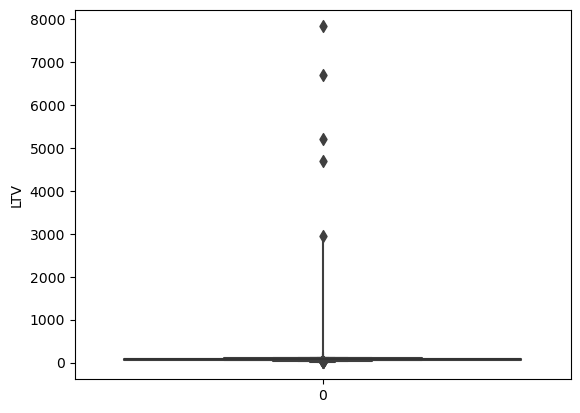

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


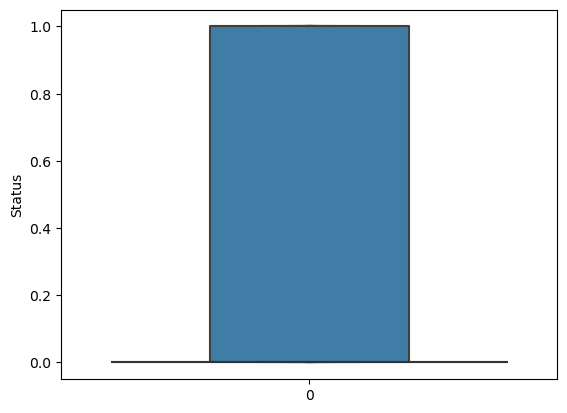

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


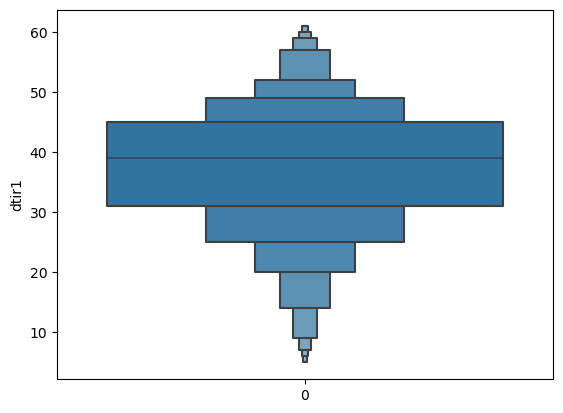

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


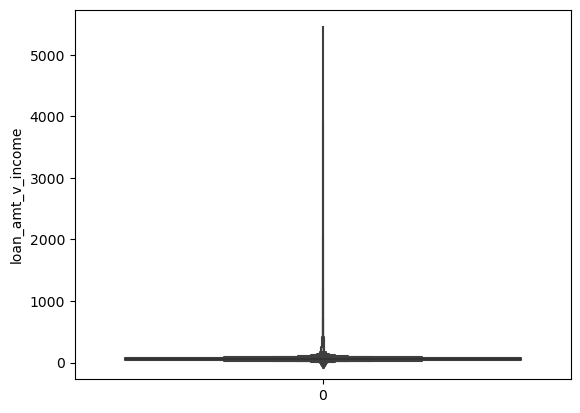

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


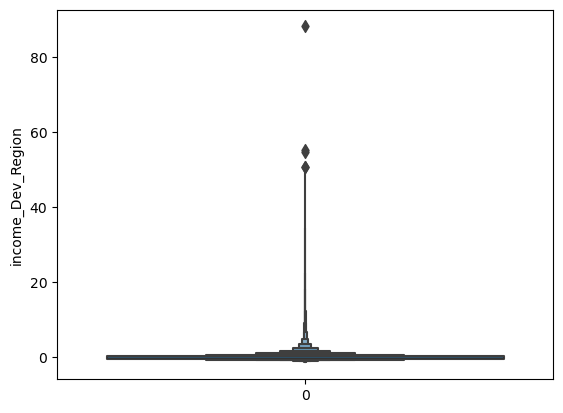

In [68]:
import matplotlib.pyplot as plt

# select numeric dtype columns and plot vs target

for column in loan_df.select_dtypes("number").columns:
    sns.boxenplot(loan_df[column]).set(ylabel=column)
    plt.show()

<Axes: ylabel='Gender'>

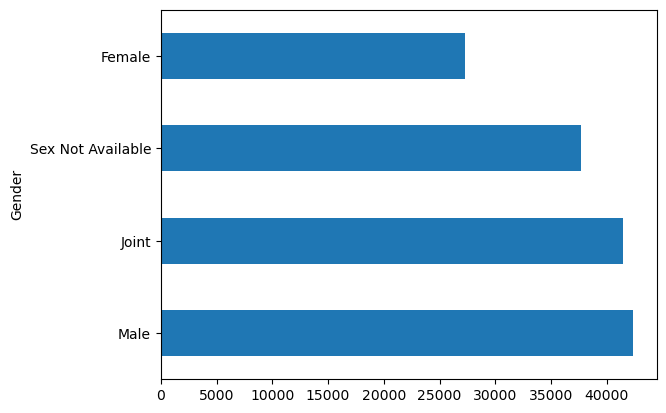

In [69]:
loan_df["Gender"].value_counts().plot.barh()

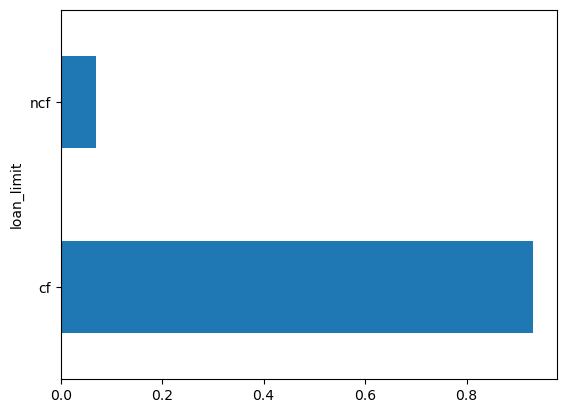

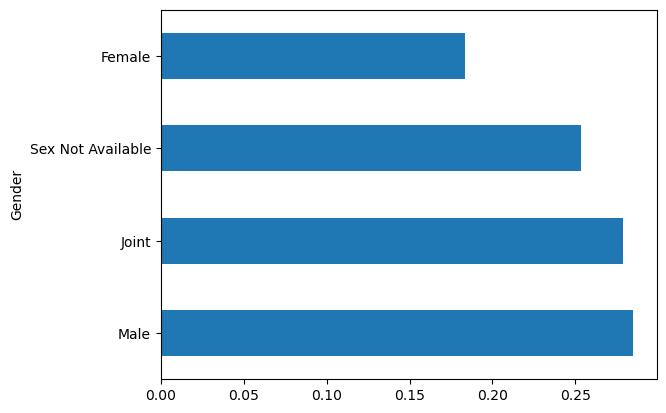

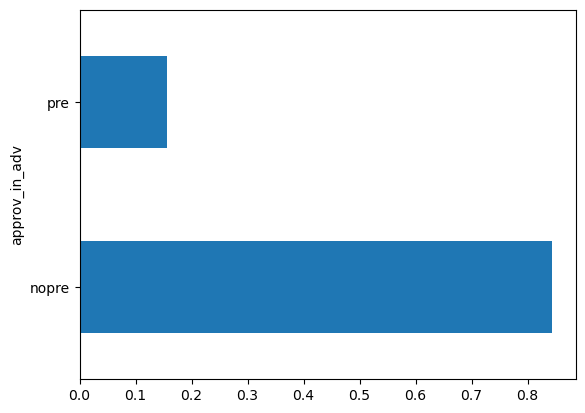

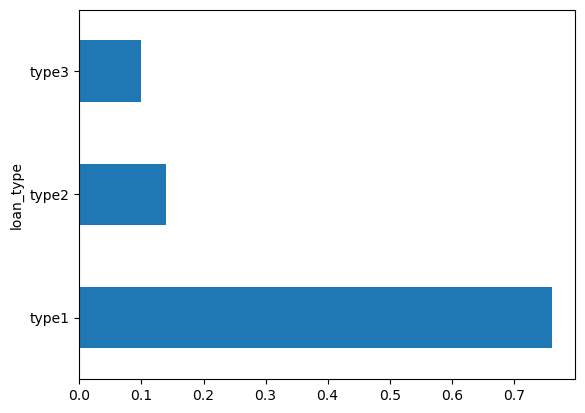

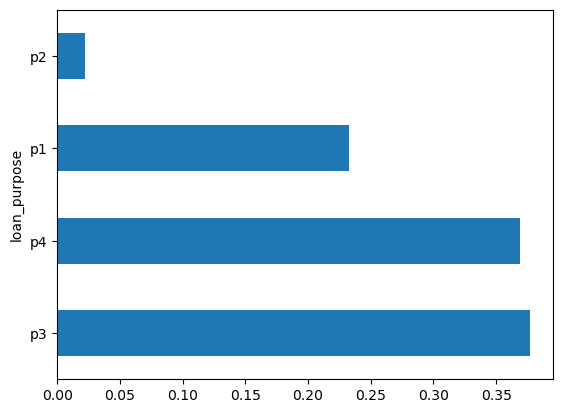

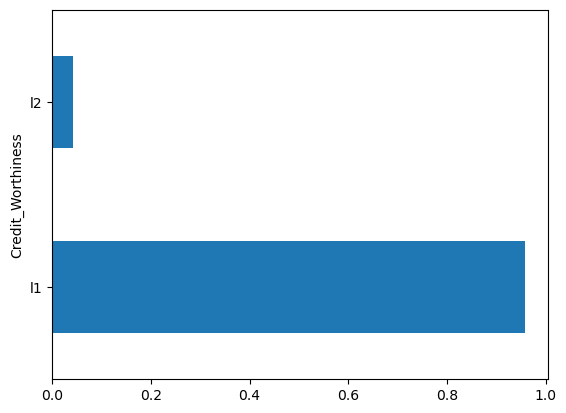

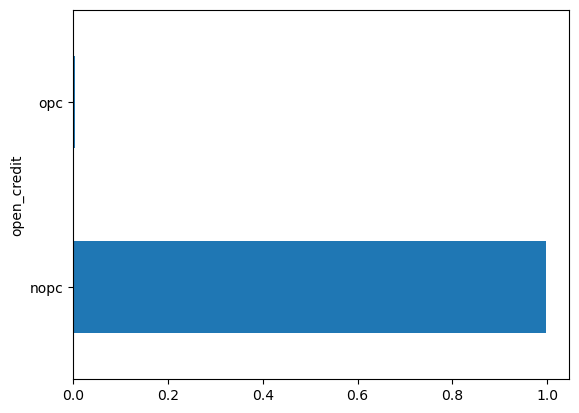

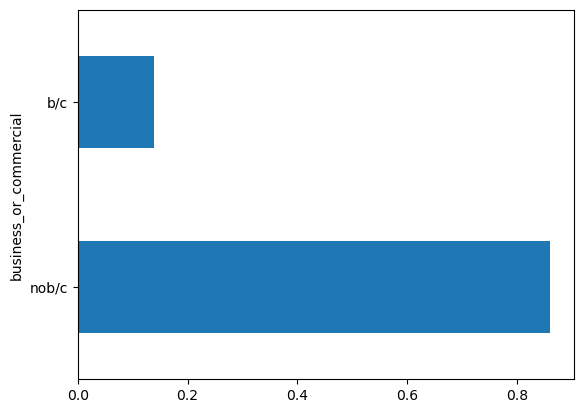

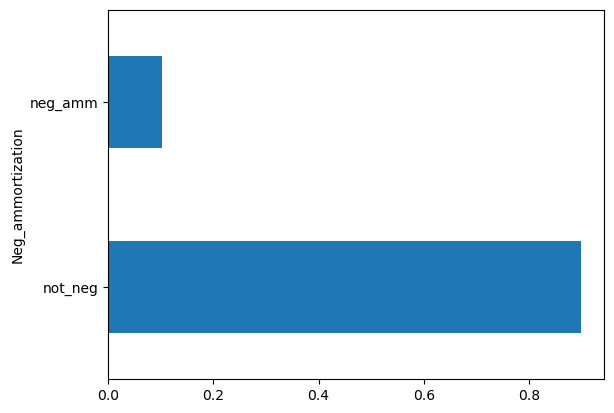

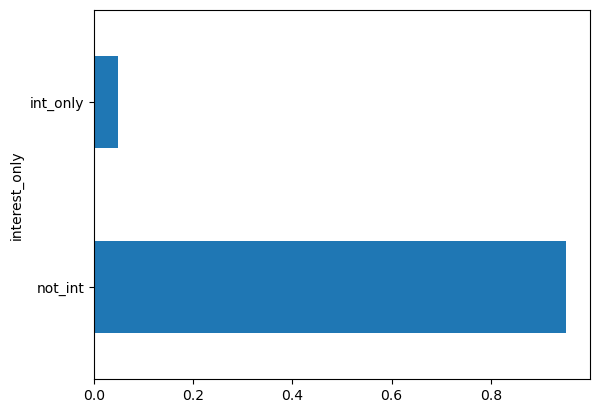

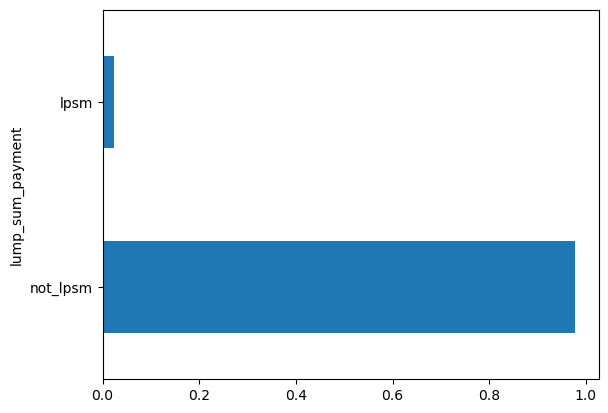

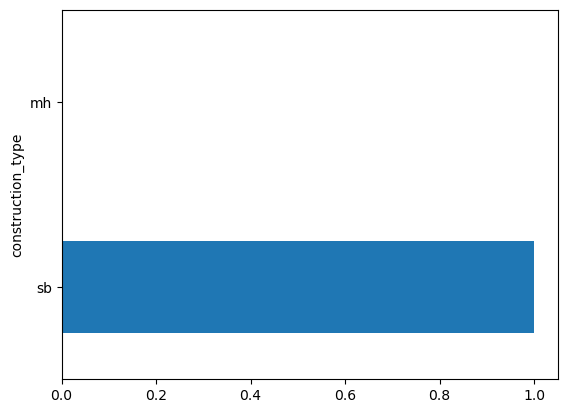

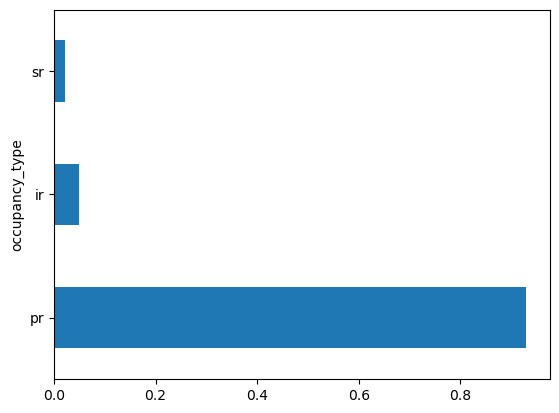

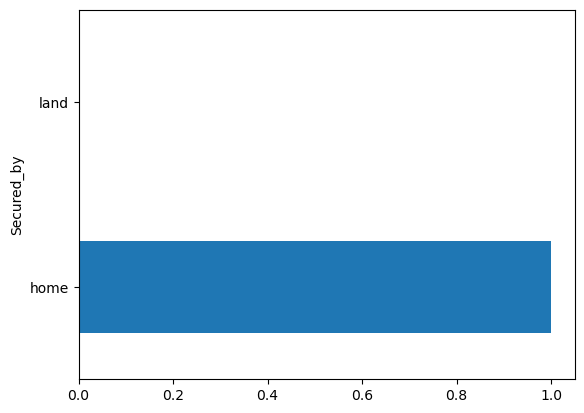

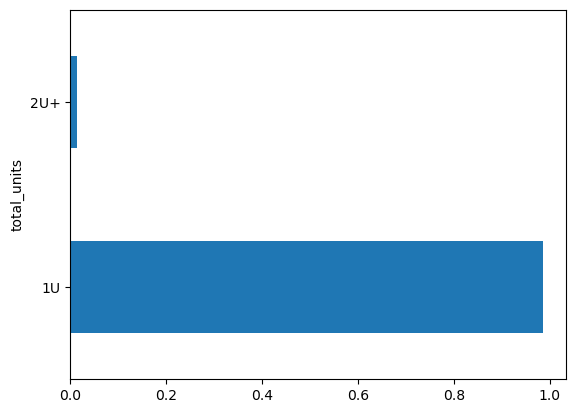

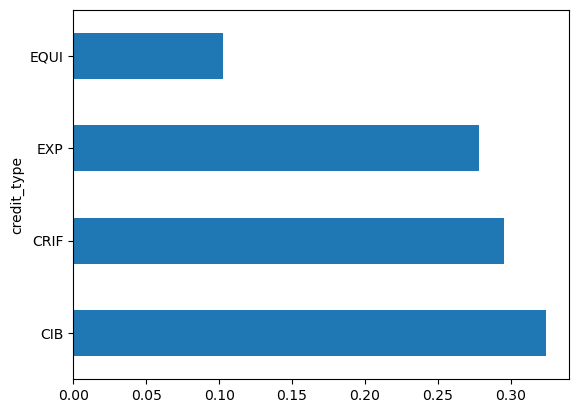

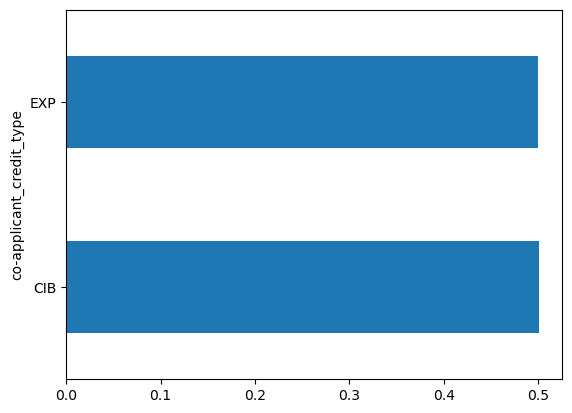

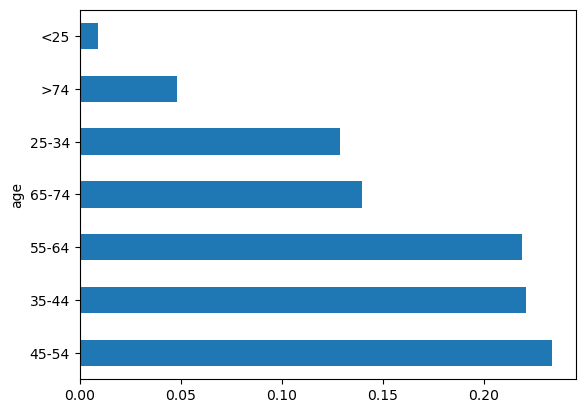

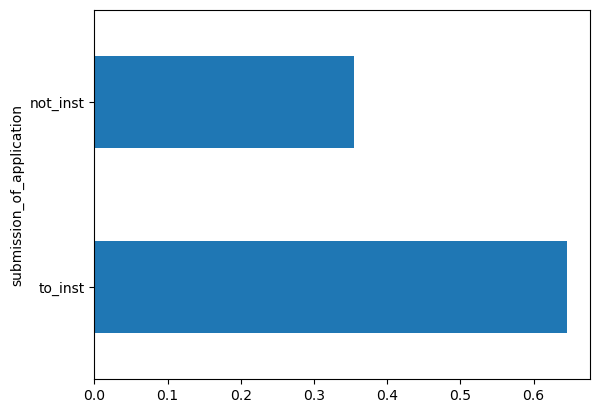

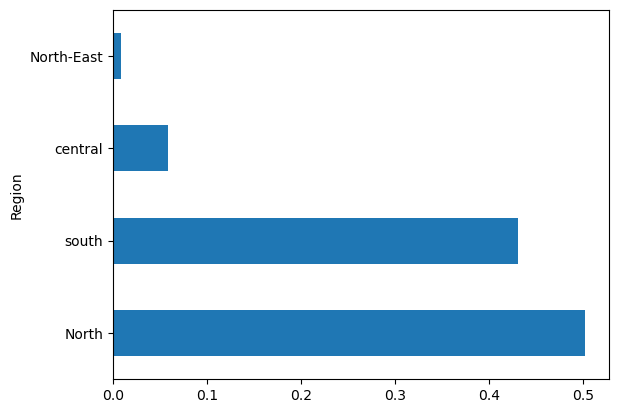

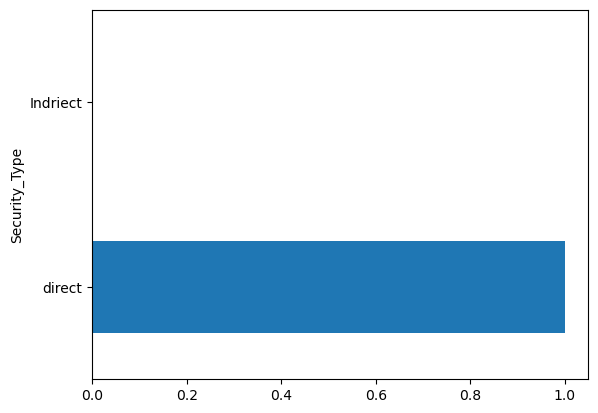

In [70]:
# select object dtype columns and plot vs target

for column in loan_df.select_dtypes("object").columns:
    loan_df[column].value_counts(normalize=True).plot.barh()
    plt.show()

## Correlation

In [15]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

<Axes: xlabel='loan_amount', ylabel='property_value'>

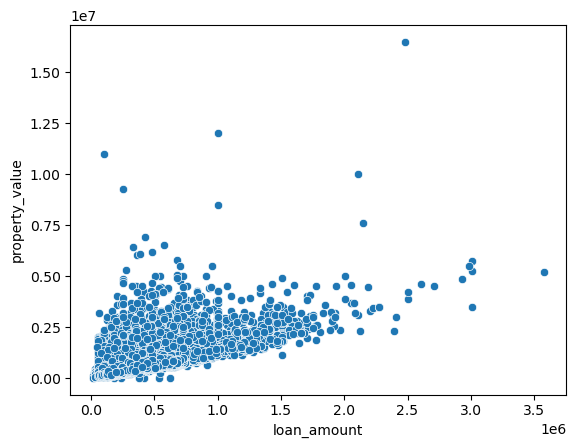

In [16]:
sns.scatterplot(loan_df, x="loan_amount", y="property_value")

In [17]:
loan_df["loan_amount"].corr(loan_df["property_value"])

0.7342490169595279

<Axes: xlabel='loan_amount', ylabel='Status'>

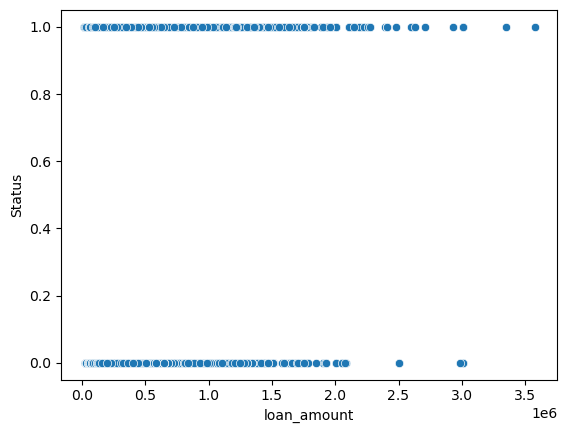

In [18]:
sns.scatterplot(loan_df, x="loan_amount", y="Status")

In [19]:
loan_df["loan_amount"].corr(loan_df["Status"])

-0.0368252755443805

In [71]:
loan_df.corr(numeric_only=True).round(2)

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1,loan_amt_v_income,income_Dev_Region
ID,1.00,NaN,-0.00,0.00,0.00,-0.01,-0.00,0.00,0.00,-0.00,-0.01,0.00,-0.01,-0.00,0.00
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount,-0.00,NaN,1.00,-0.15,-0.38,0.07,0.17,0.73,0.46,0.00,0.04,-0.04,0.02,0.10,0.46
rate_of_interest,0.00,NaN,-0.15,1.00,0.61,-0.08,0.21,-0.12,-0.04,-0.00,-0.00,0.02,0.06,-0.07,-0.04
Interest_rate_spread,0.00,NaN,-0.38,0.61,1.00,0.03,-0.16,-0.33,-0.15,-0.00,0.04,NaN,0.08,-0.17,-0.15
Upfront_charges,-0.01,NaN,0.07,-0.08,0.03,1.00,-0.05,0.05,0.02,-0.00,-0.03,-0.02,0.00,0.04,0.02
term,-0.00,NaN,0.17,0.21,-0.16,-0.05,1.00,0.05,-0.05,-0.00,0.11,-0.00,0.11,0.08,-0.05
property_value,0.00,NaN,0.73,-0.12,-0.33,0.05,0.05,1.00,0.41,0.00,-0.22,-0.05,-0.06,0.07,0.42
income,0.00,NaN,0.46,-0.04,-0.15,0.02,-0.05,0.41,1.00,0.00,-0.07,-0.07,-0.27,-0.11,1.00
Credit_Score,-0.00,NaN,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,1.00,-0.01,0.00,-0.00,-0.00,0.00


<Axes: >

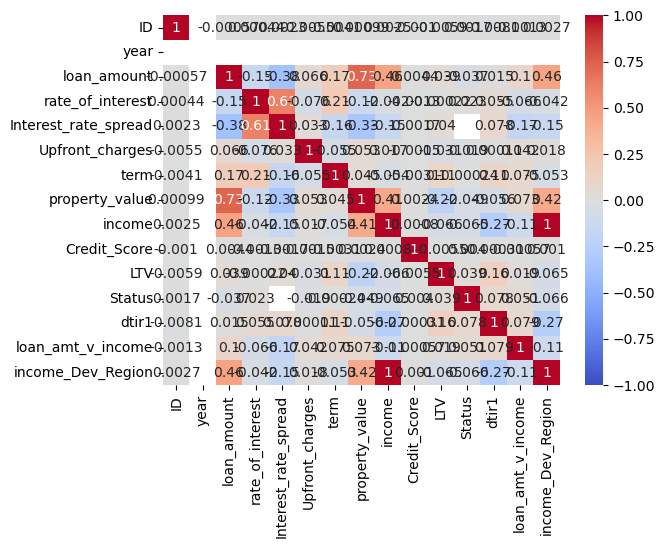

In [ ]:
sns.heatmap(
    loan_df.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    cmap="coolwarm", #annot=True
)

<Axes: >

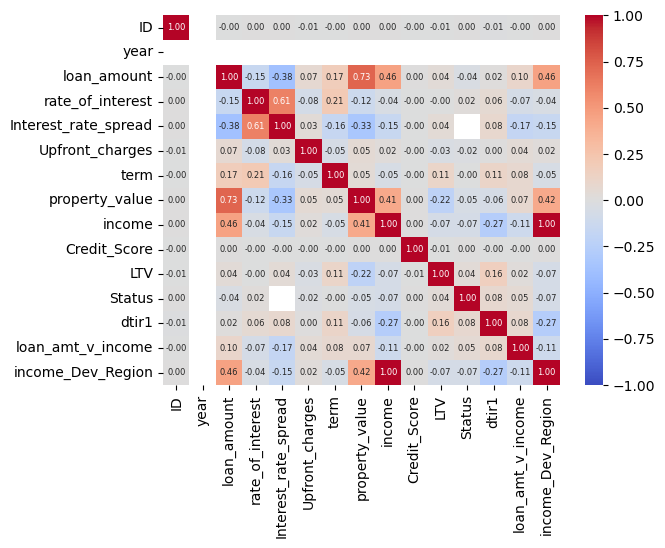

In [74]:
sns.heatmap(
    loan_df.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size":6}
)

## Feature Target Relationships

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Status', ylabel='loan_amount'>

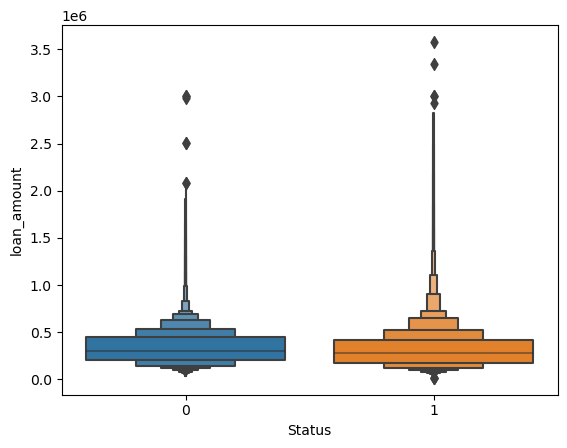

In [76]:
sns.boxenplot(loan_df, x="Status", y="loan_amount")

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


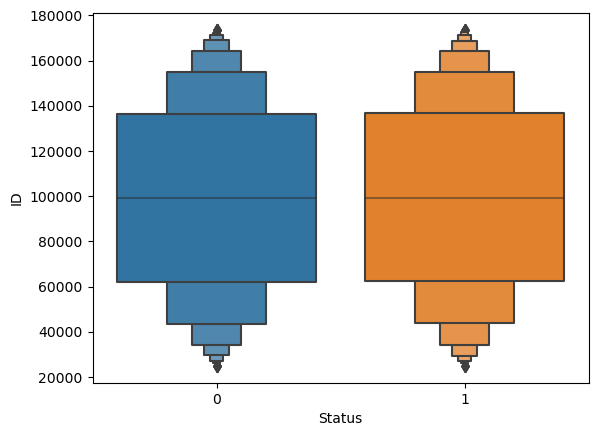

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


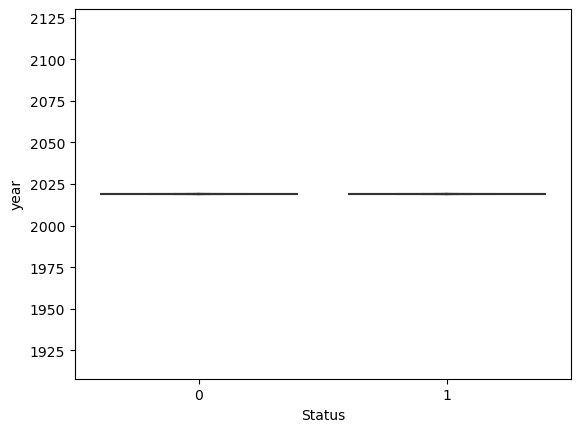

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


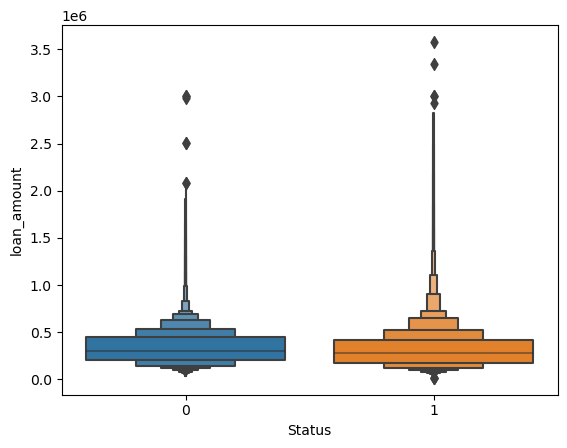

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


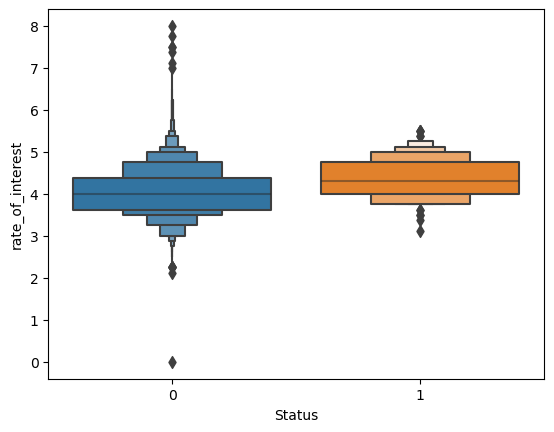

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


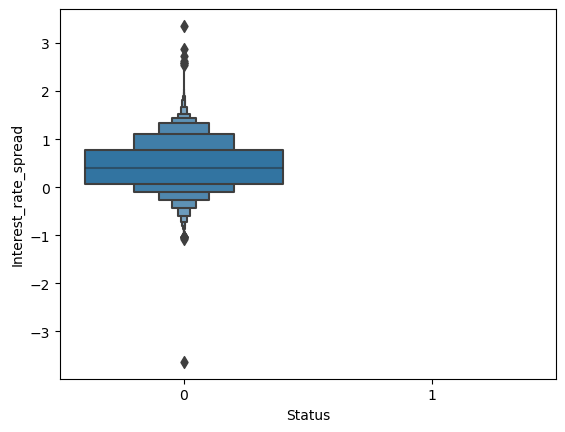

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


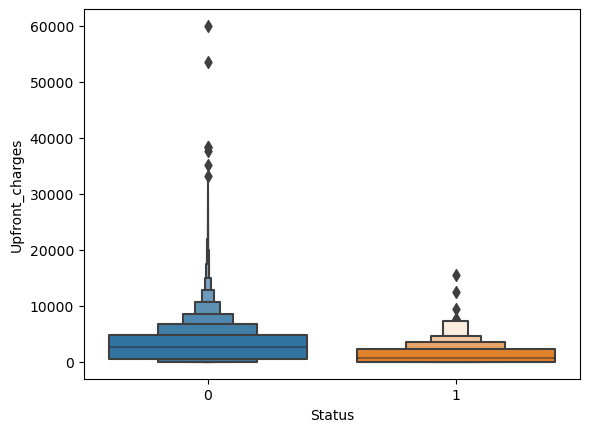

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


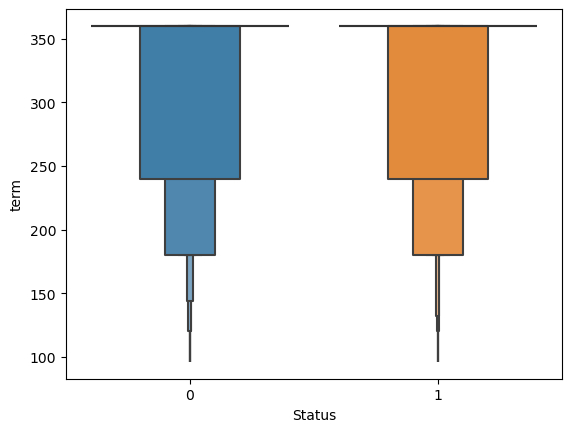

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


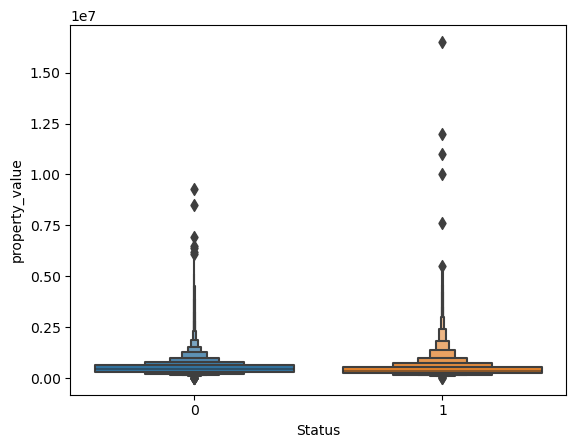

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


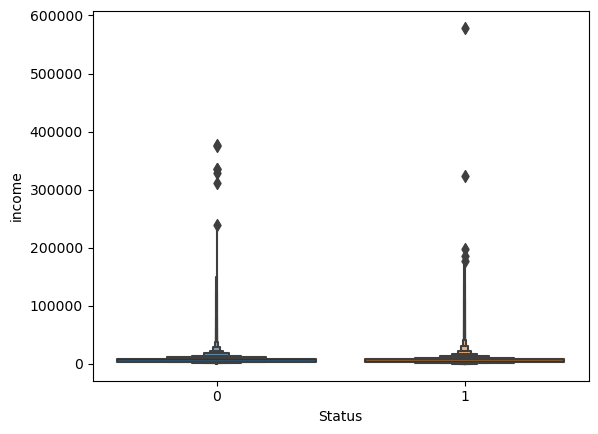

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


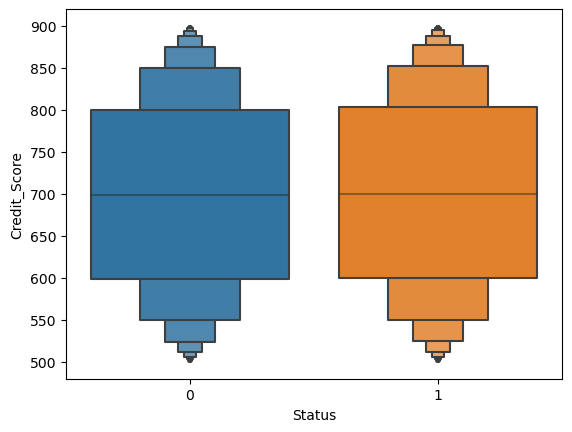

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


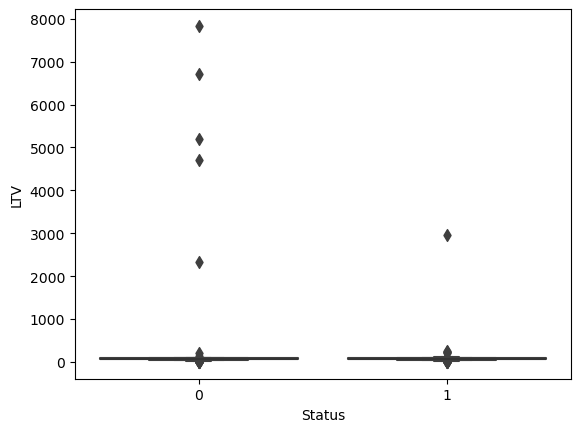

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


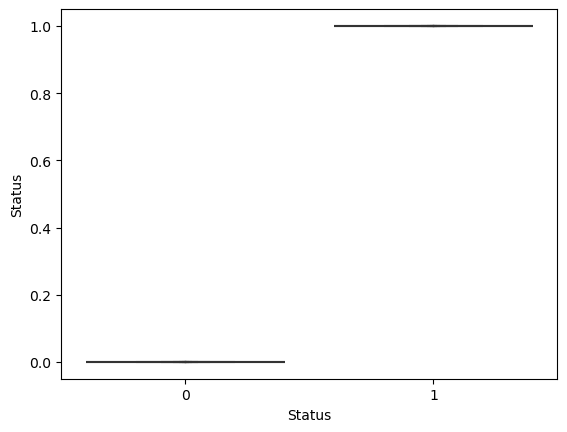

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


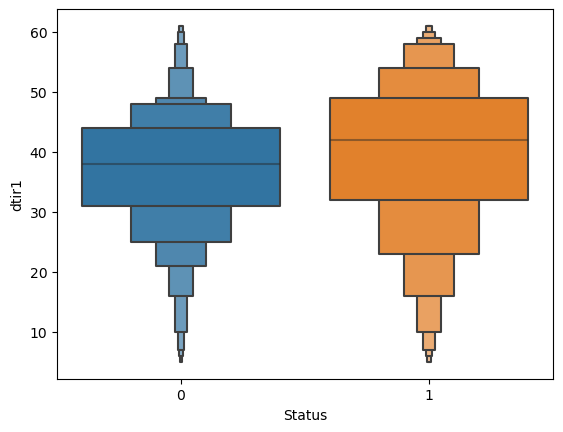

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


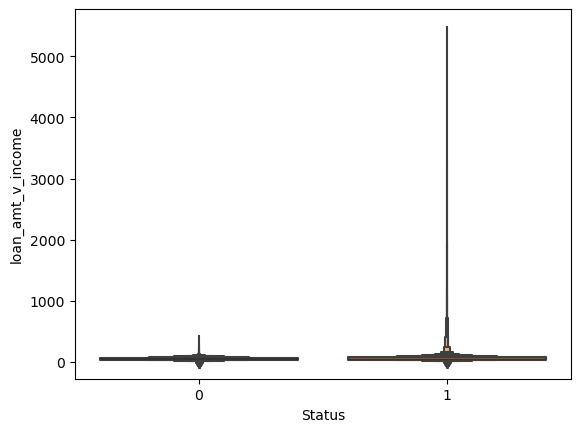

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


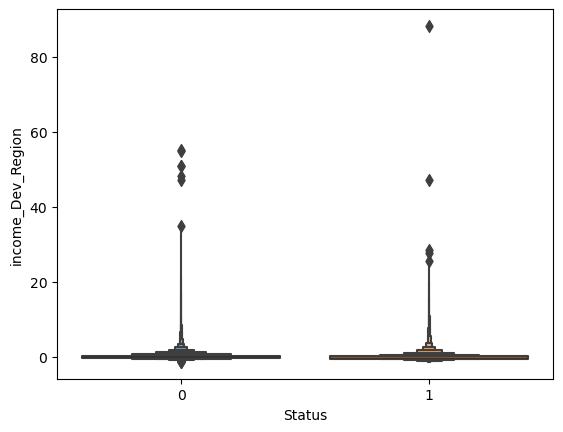

In [77]:
def box_target_plotter(data, target):
    for col in data.select_dtypes("number"):
        sns.boxenplot(data=data, x=target, y=col)
        plt.show()
        
box_target_plotter(loan_df, "Status")

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='loan_amount', ylabel='Percent'>

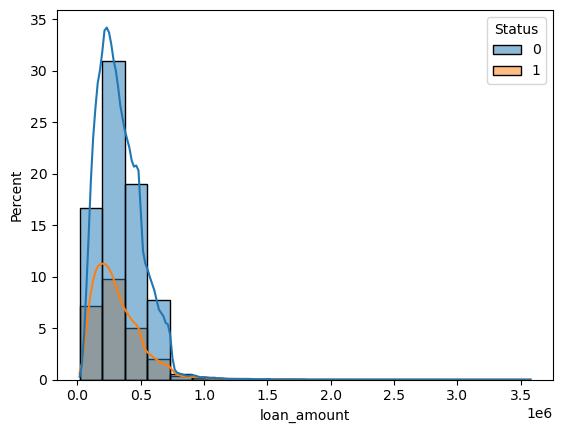

In [24]:
sns.histplot(loan_df, x="loan_amount", hue="Status", stat="percent", kde=True, bins=20)

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


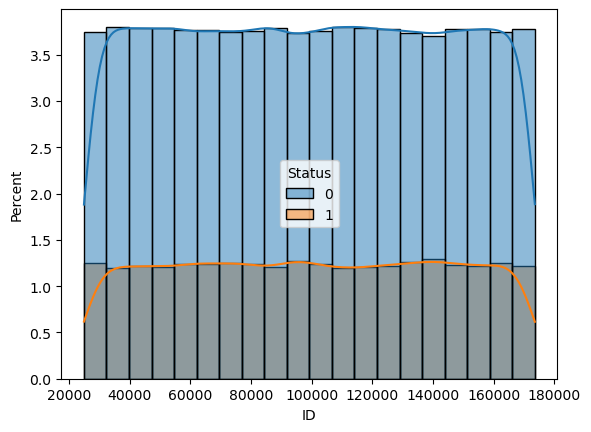

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


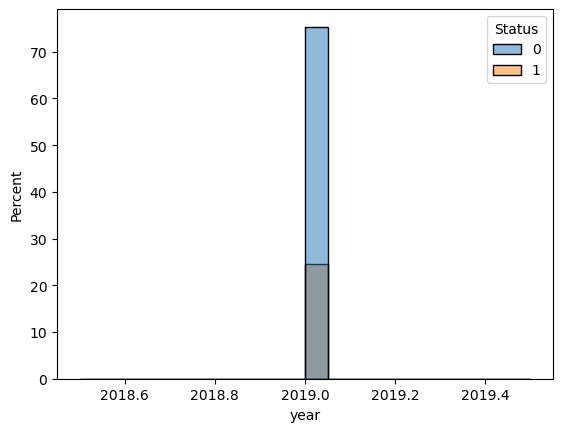

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


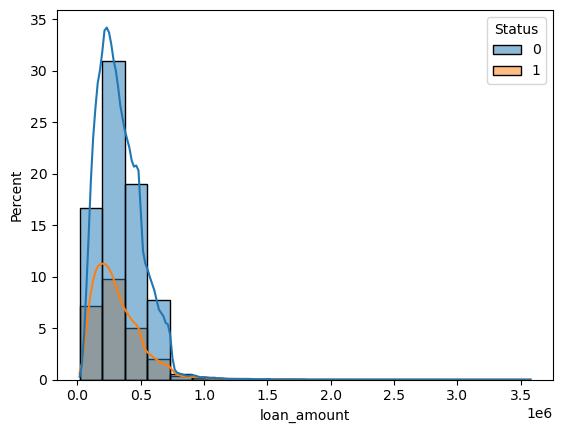

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


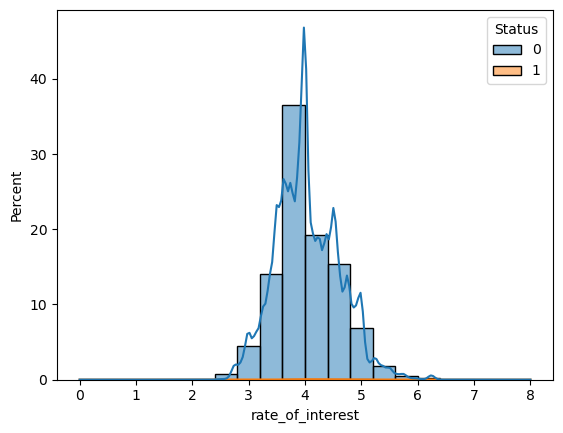

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


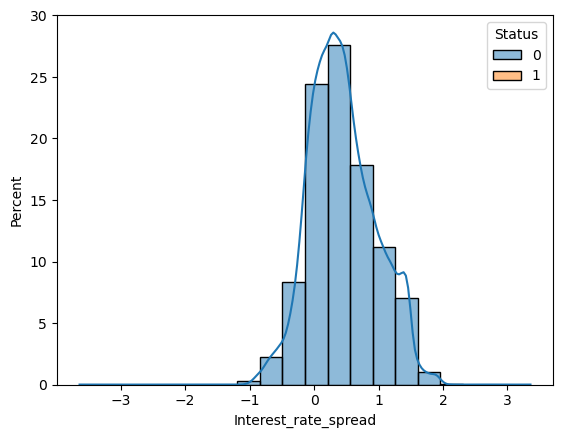

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


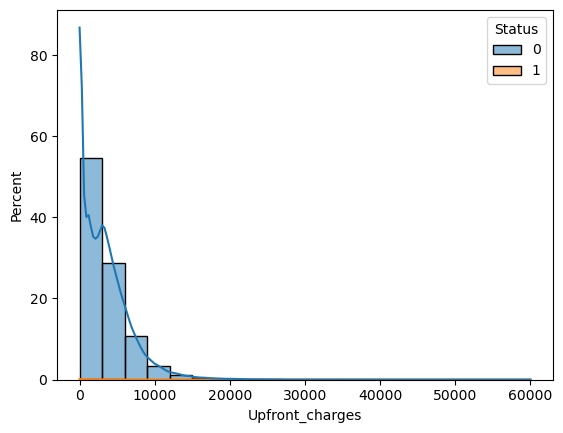

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


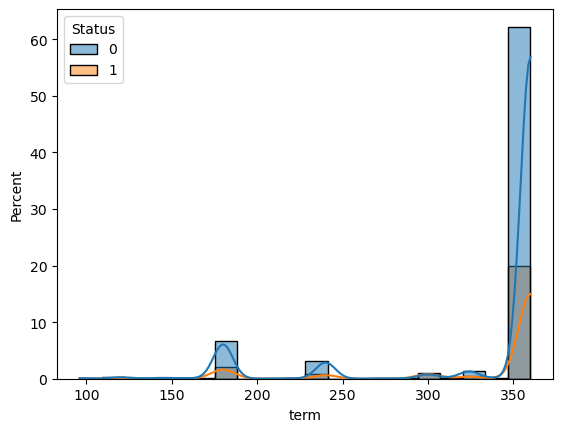

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


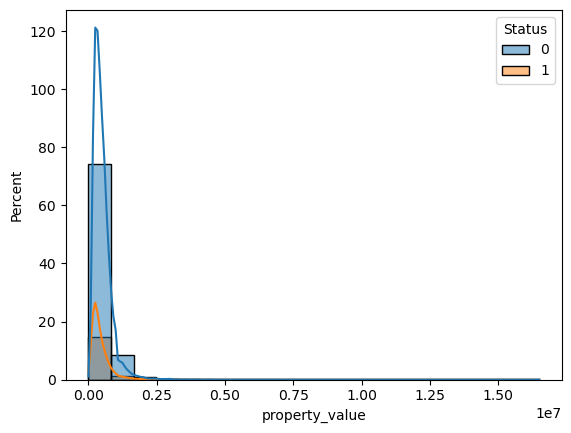

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


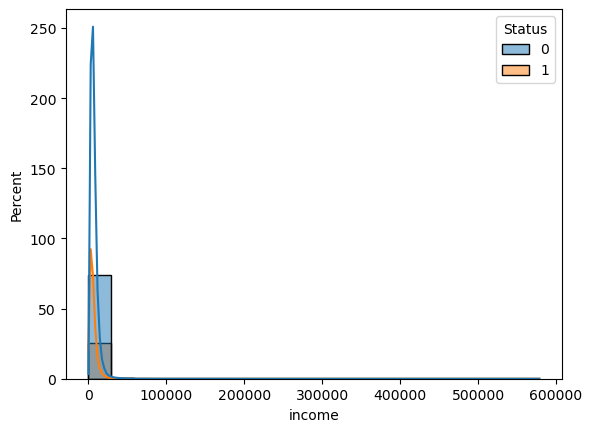

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


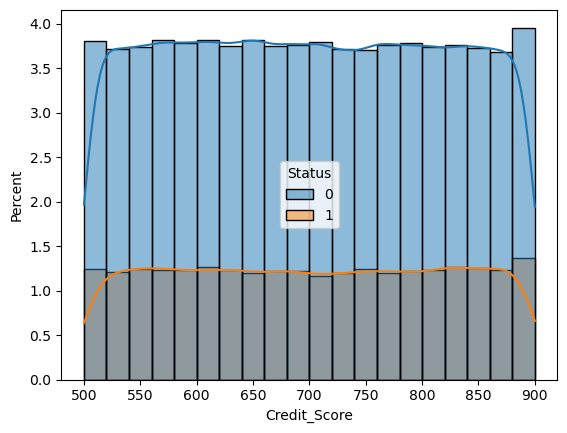

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


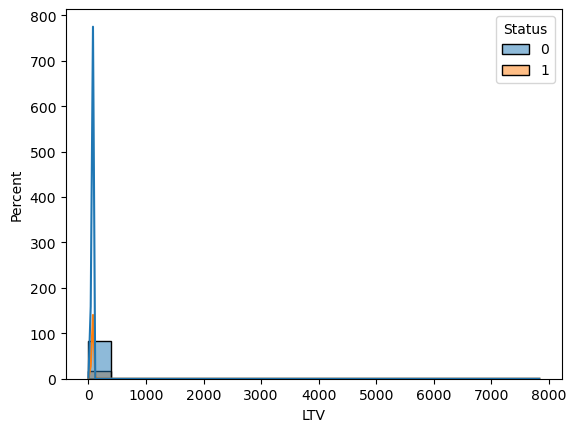

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


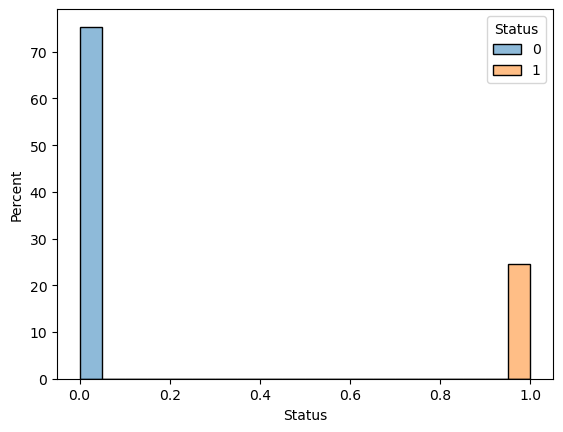

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


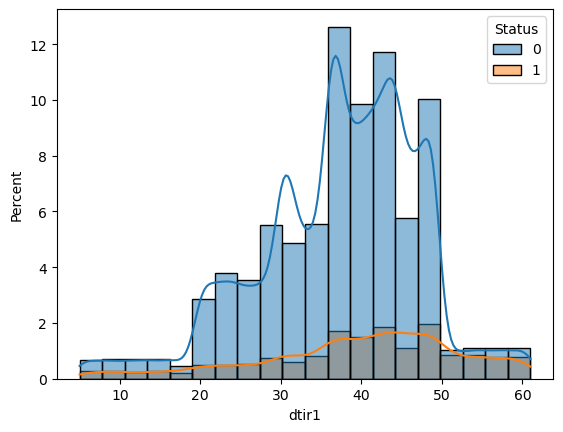

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


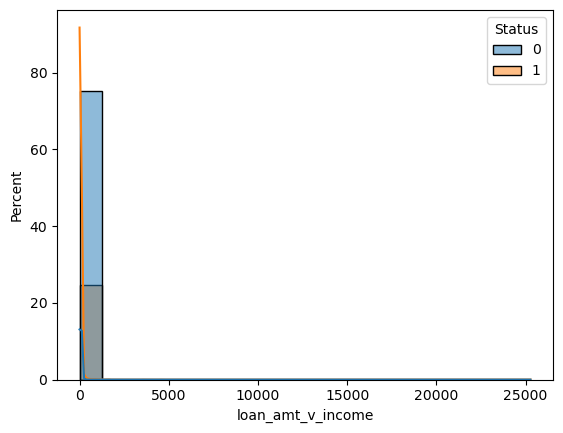

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


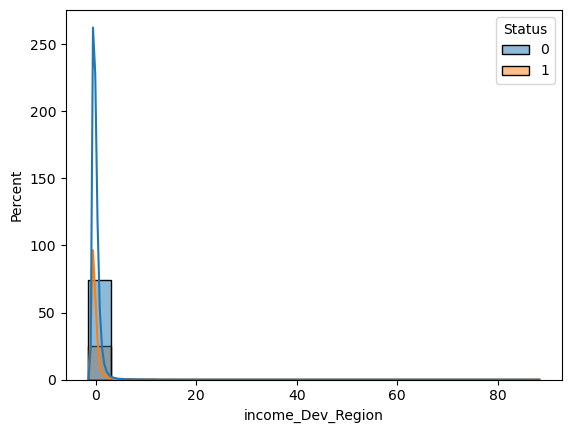

In [78]:
def hist_target_plotter(data, target):
    for col in data.select_dtypes("number"):
        sns.histplot(data=data, x=col, hue=target, stat="percent", kde=True, bins=20
                   )
        plt.show()
        
hist_target_plotter(loan_df, "Status")

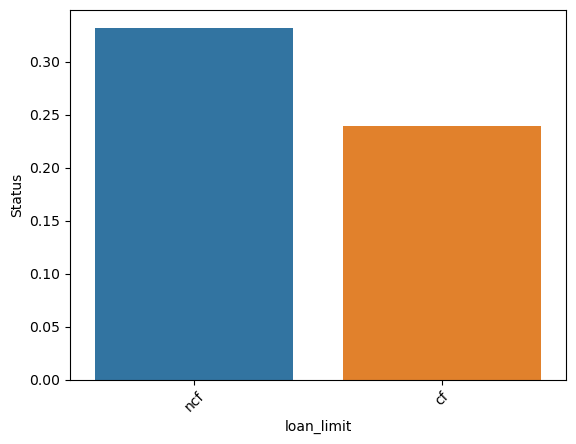

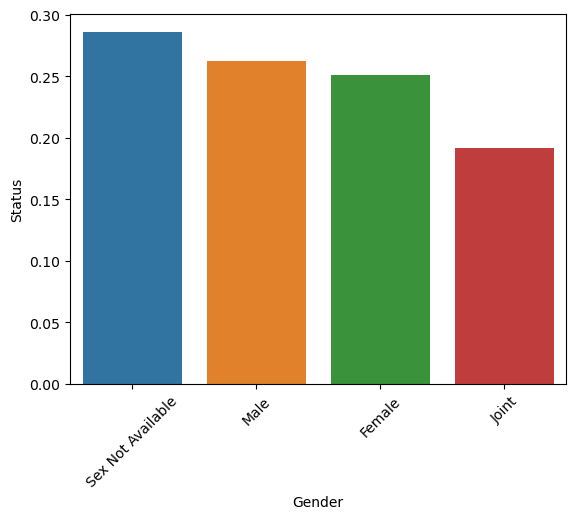

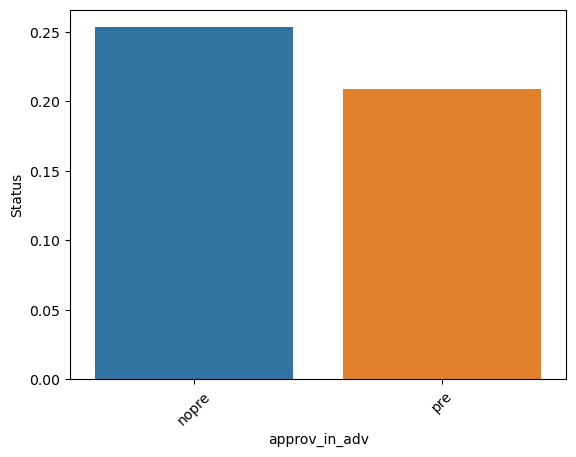

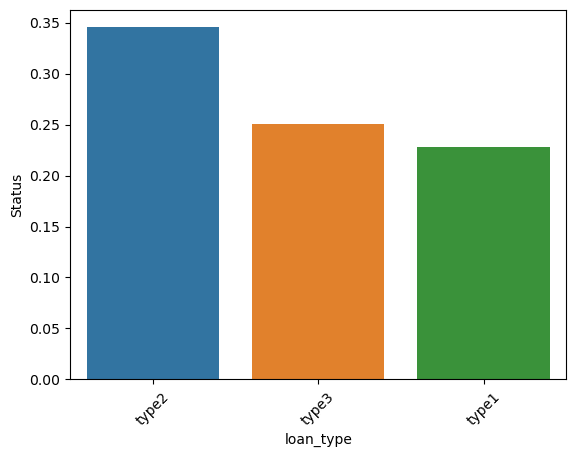

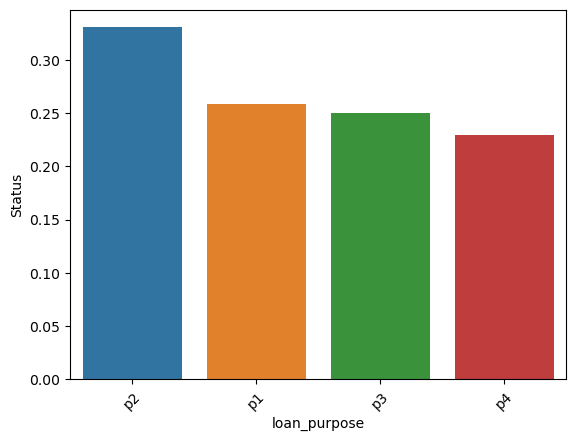

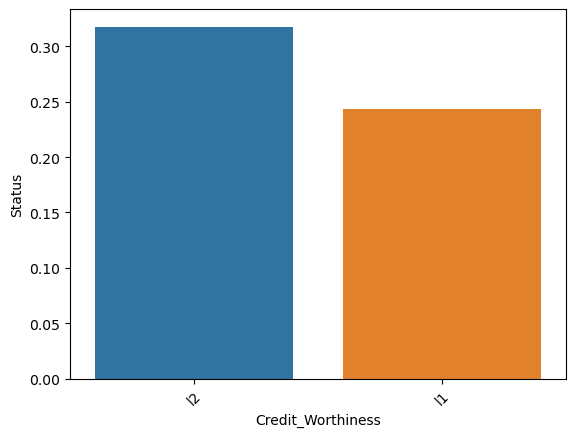

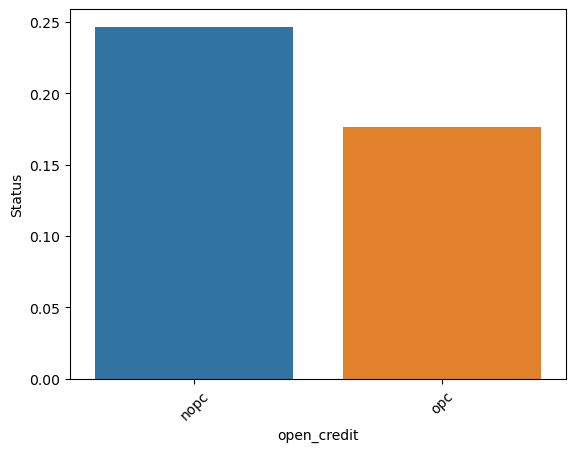

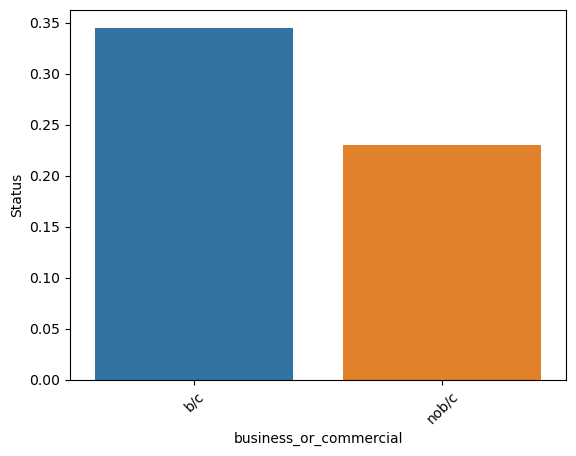

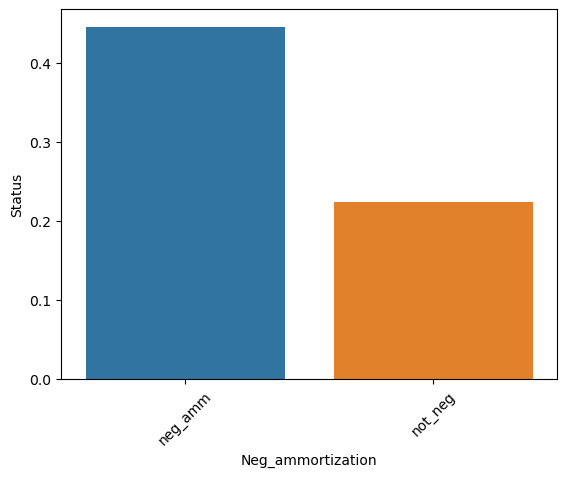

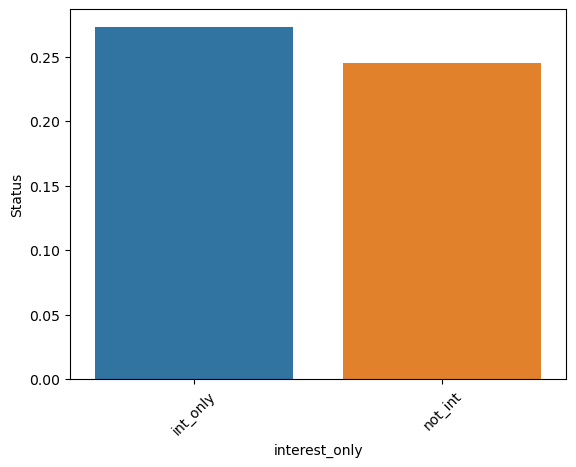

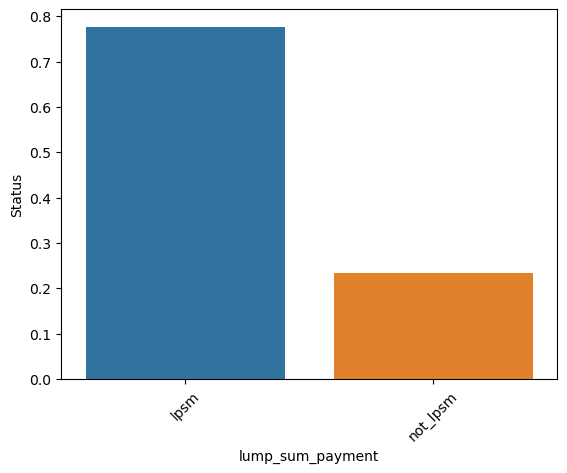

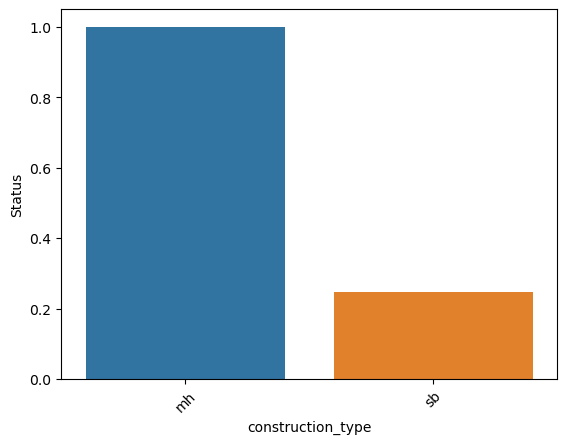

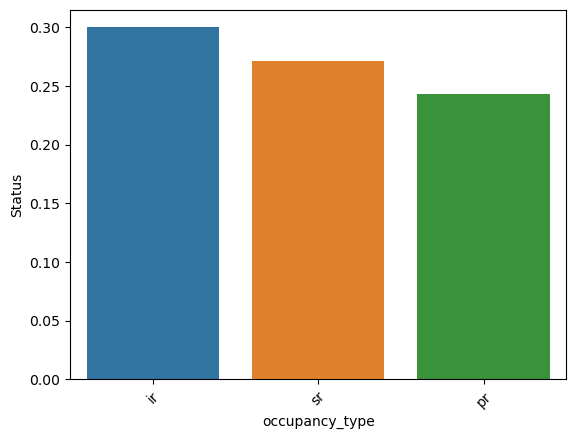

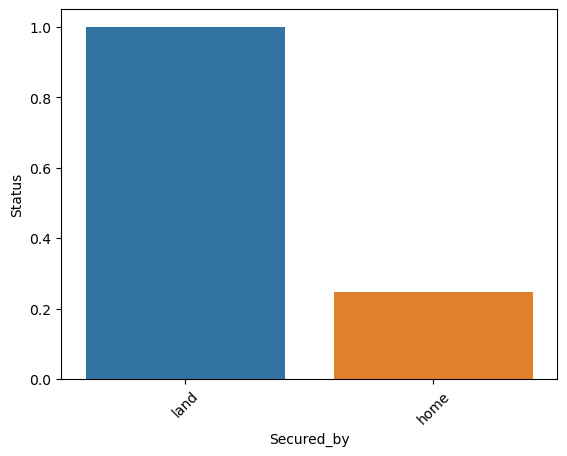

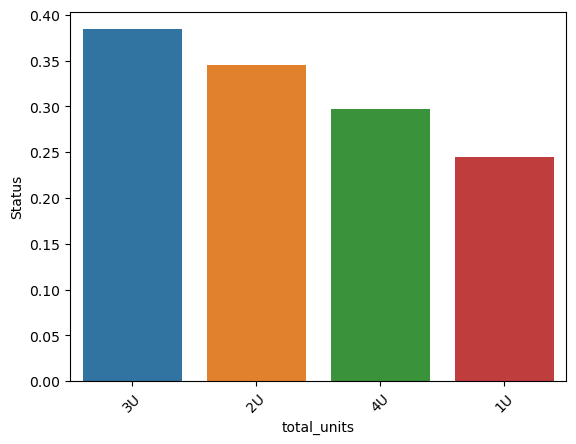

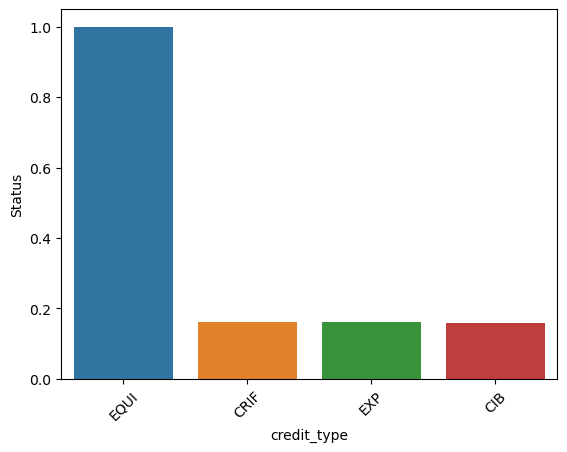

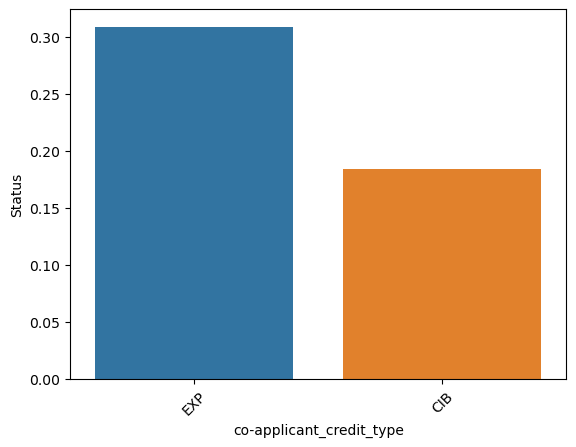

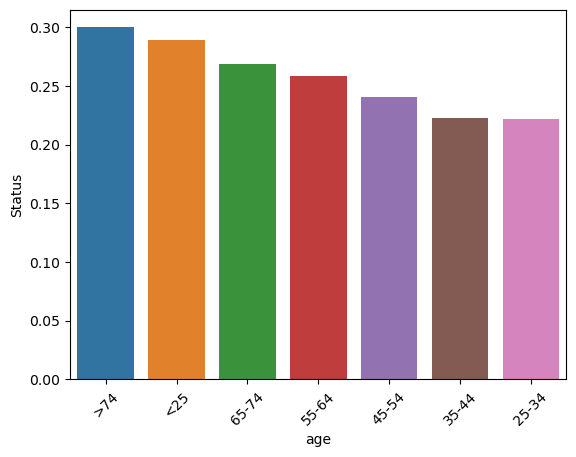

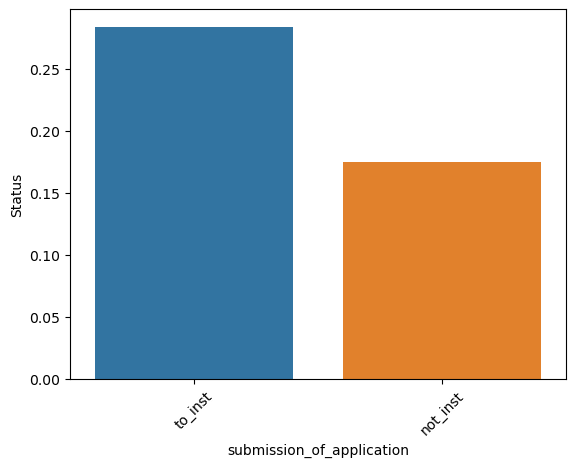

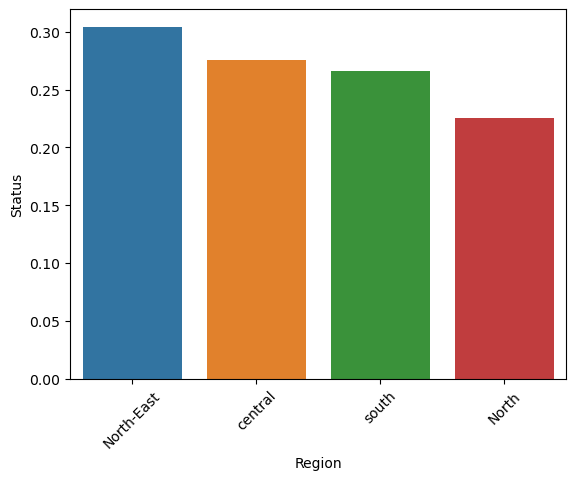

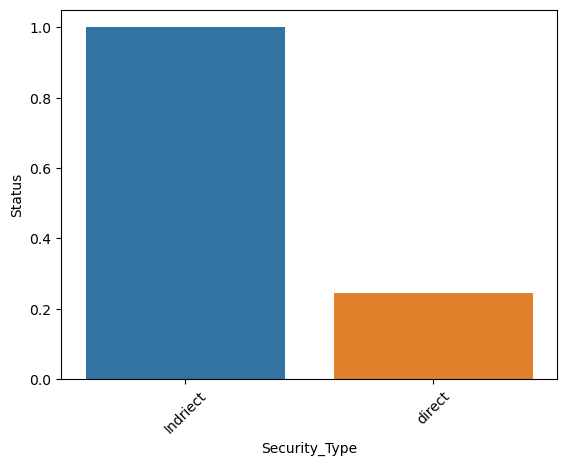

In [26]:
def cat_plotter(data, target):
    for col in data.select_dtypes(["object"]).columns:
        sns.barplot(
            data=(
                data
                .groupby(col, as_index=False)
                .agg({target: "mean"})
                .sort_values(by=target, ascending=False)
                 ), 
            x=col, 
            y=target)
        plt.xticks(rotation=45)
        plt.show()
        
cat_plotter(loan_df, "Status")

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

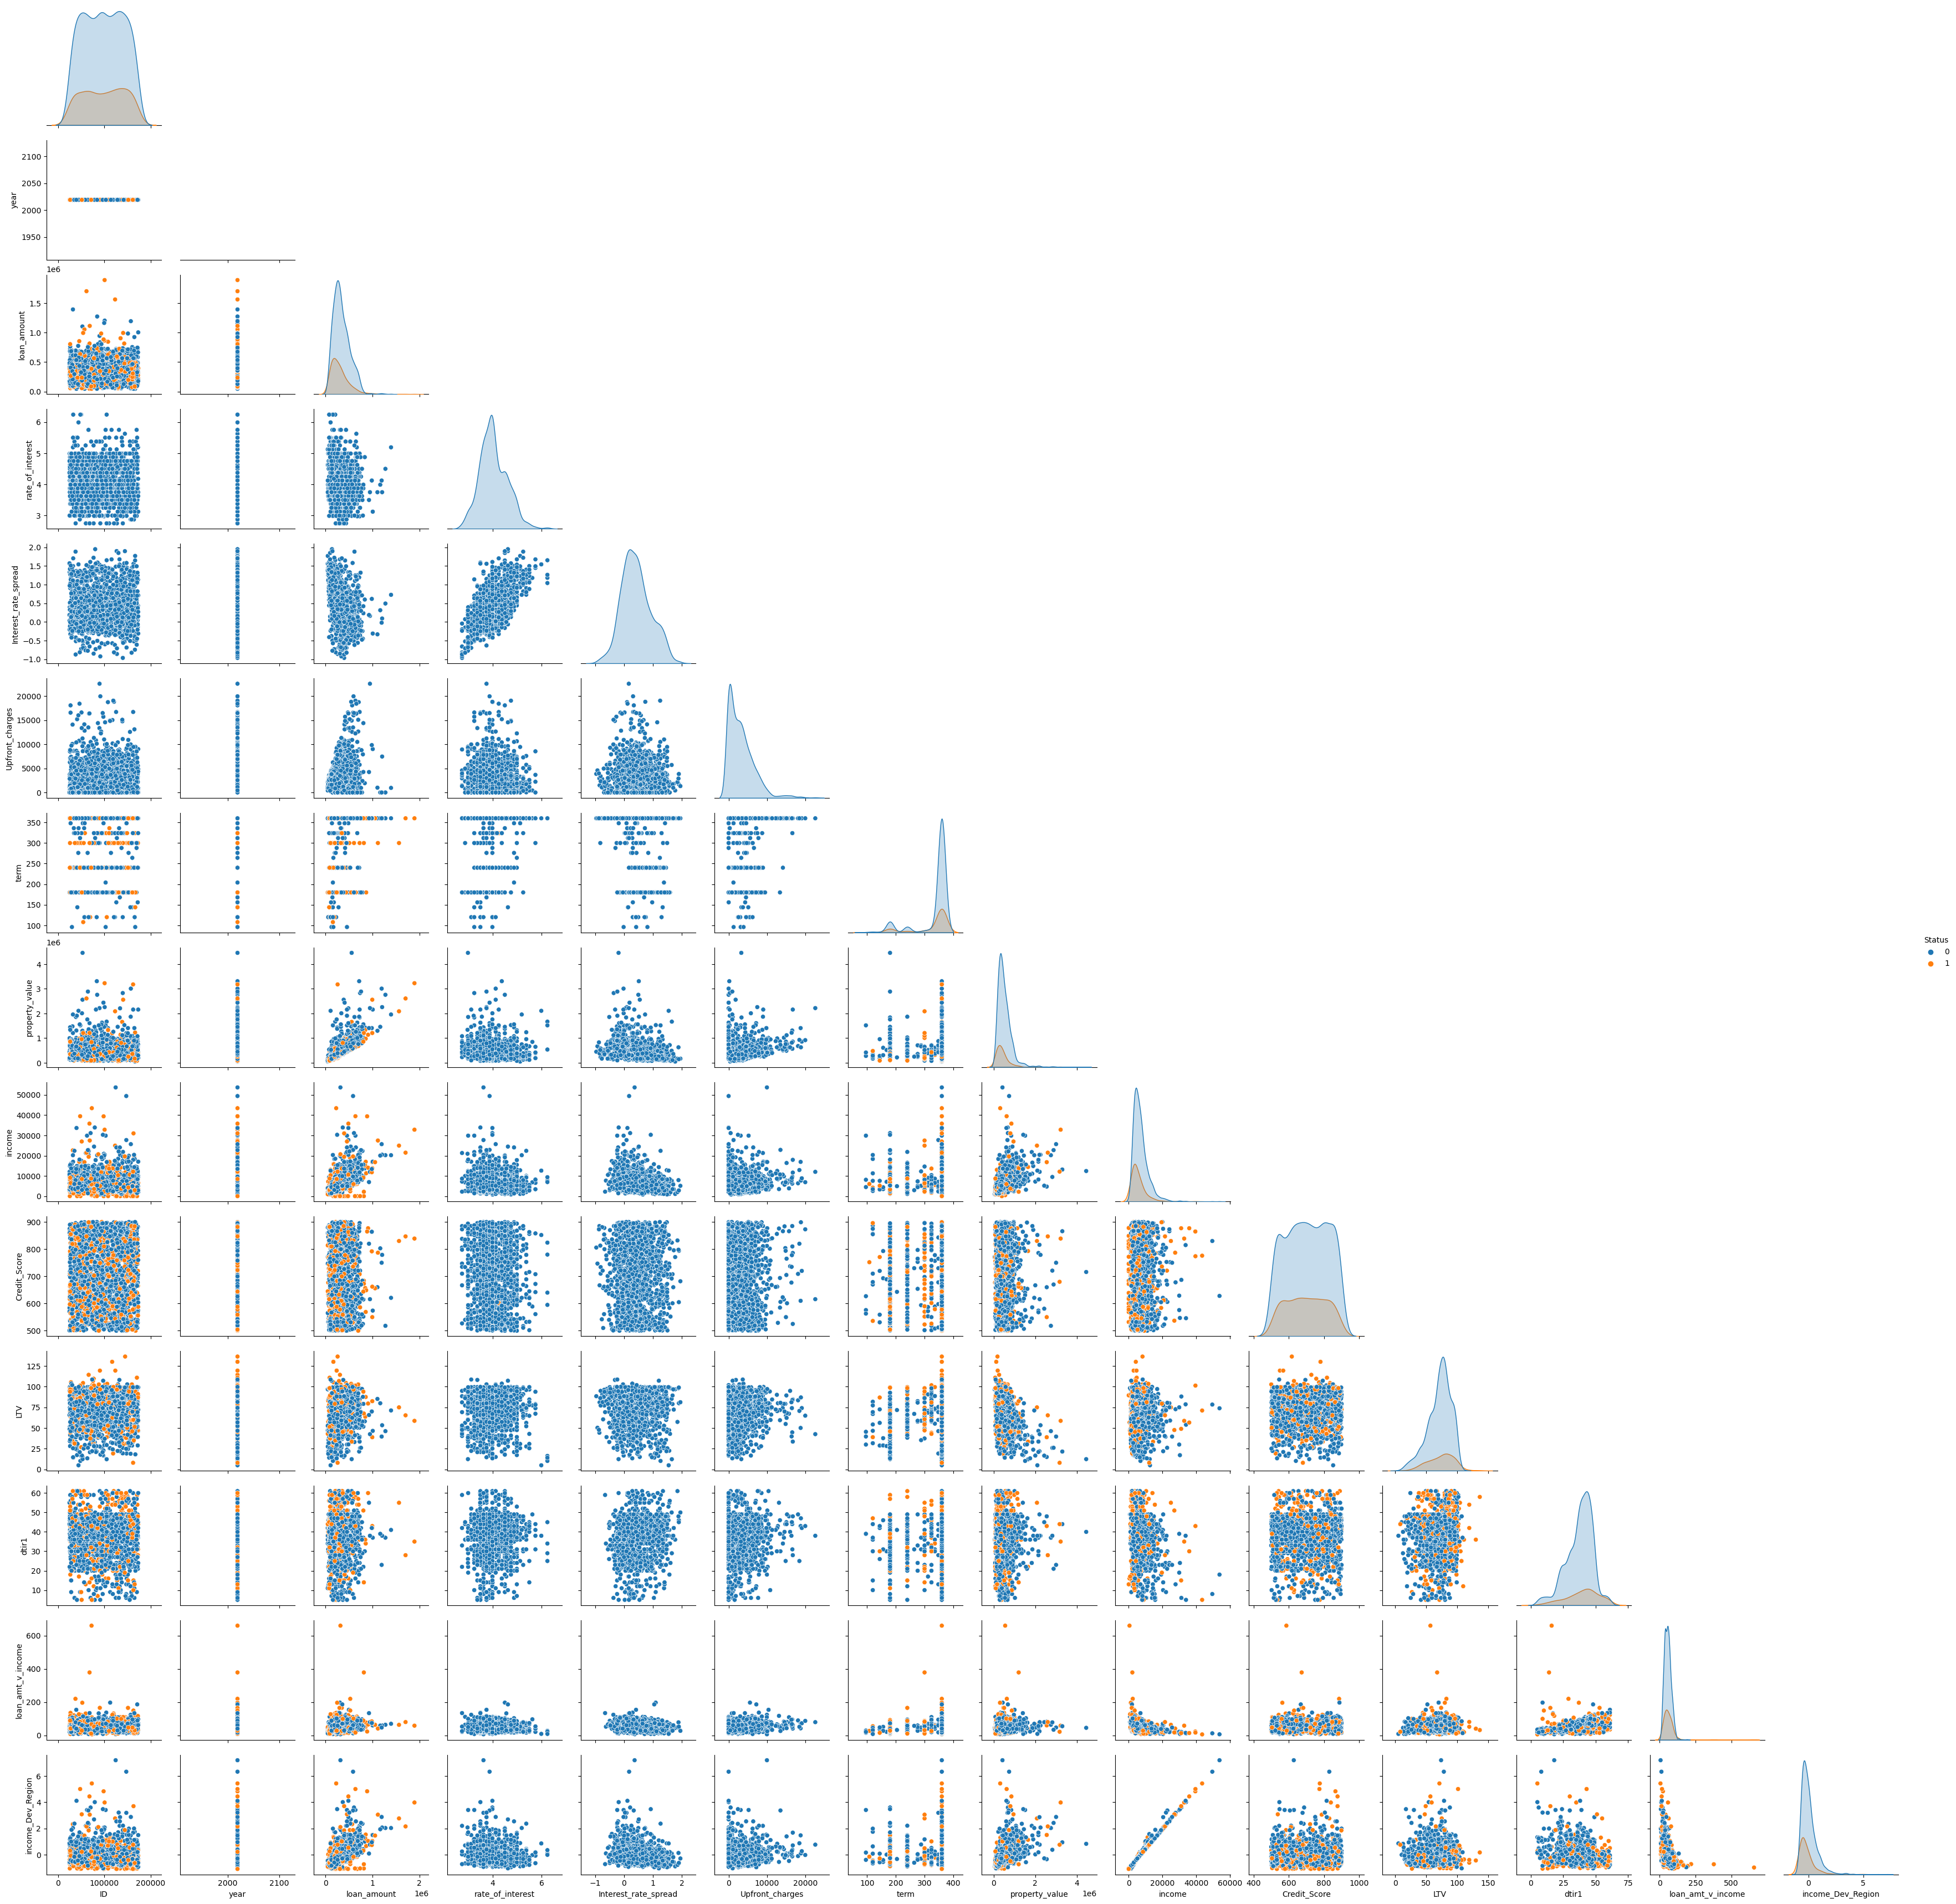

In [79]:
sns.pairplot(loan_df.sample(2000), hue="Status", corner=True)

<Axes: xlabel='loan_amount', ylabel='income'>

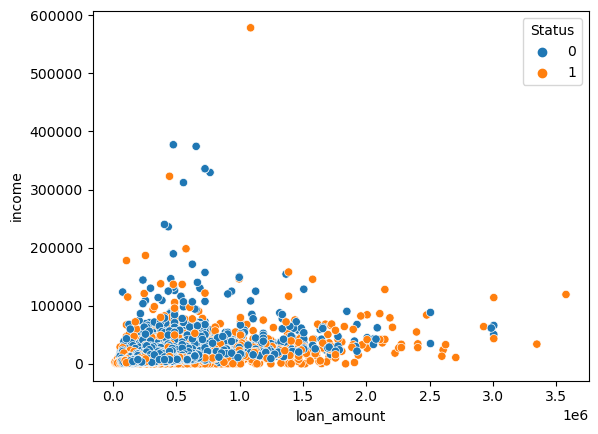

In [28]:
sns.scatterplot(loan_df, x="loan_amount", y="income", hue="Status" )

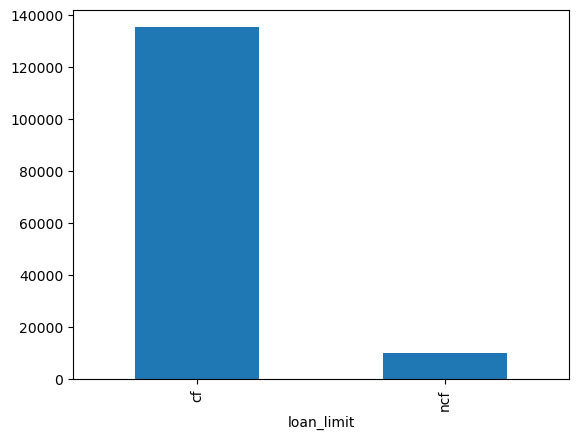

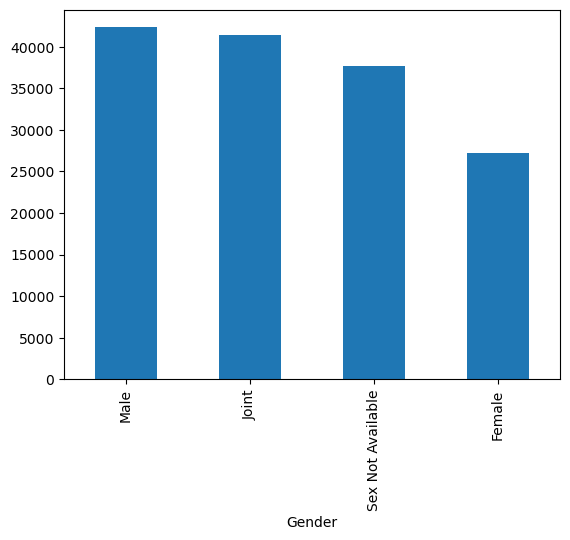

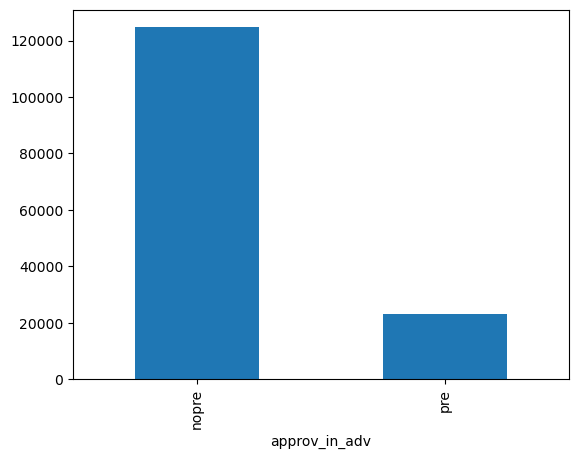

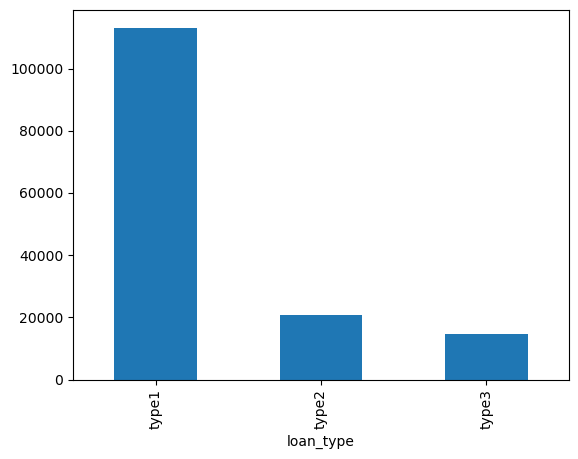

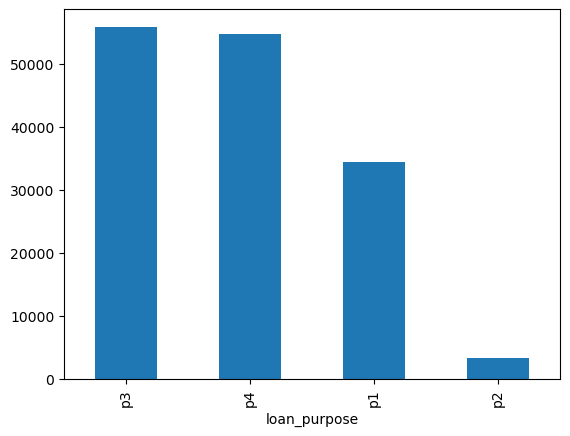

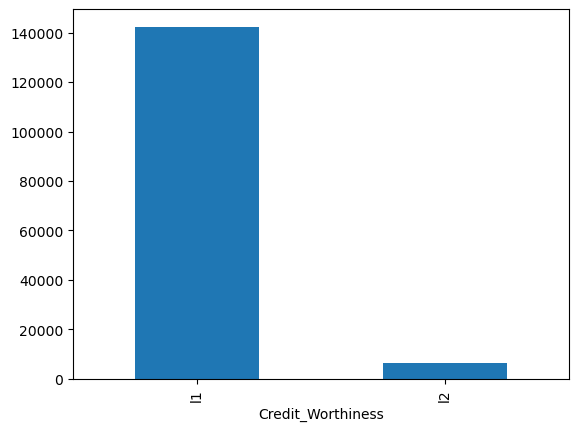

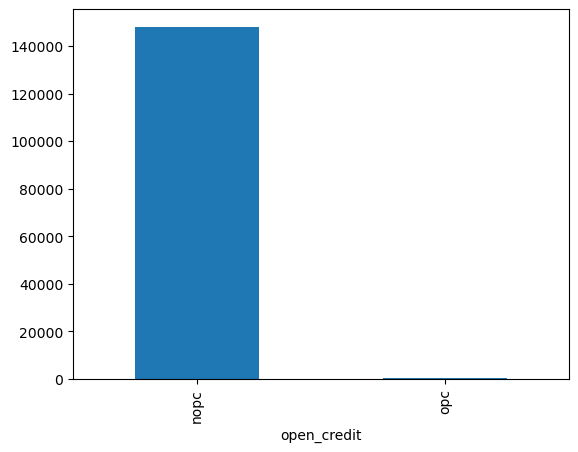

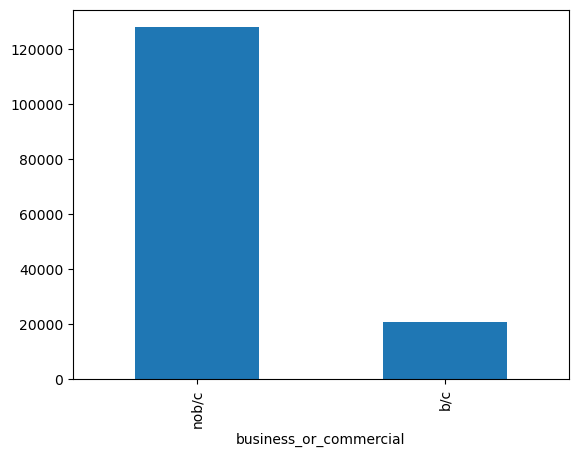

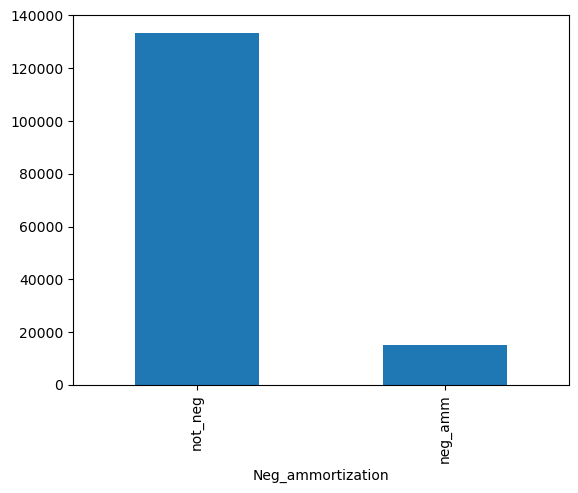

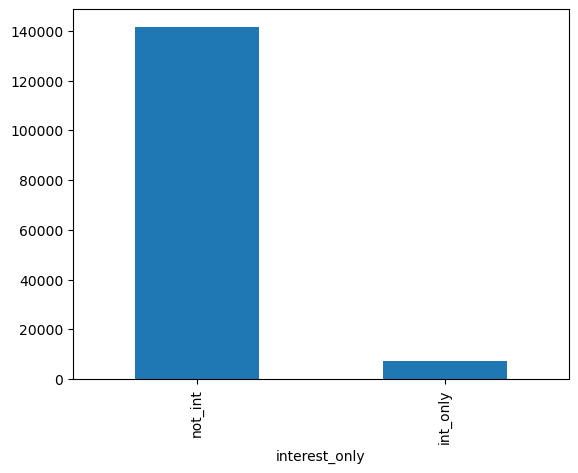

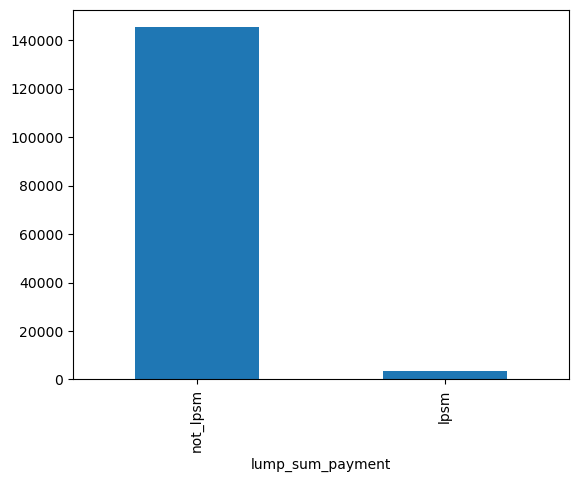

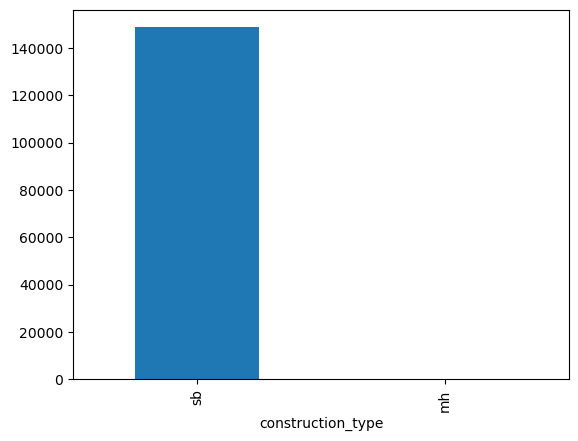

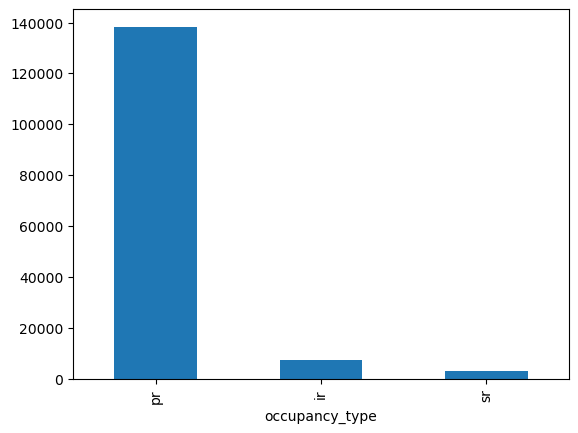

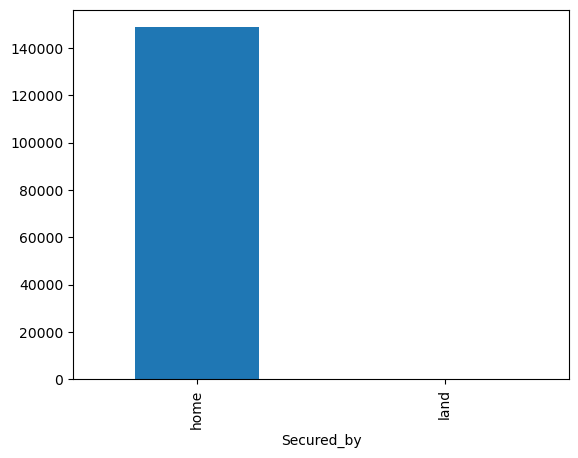

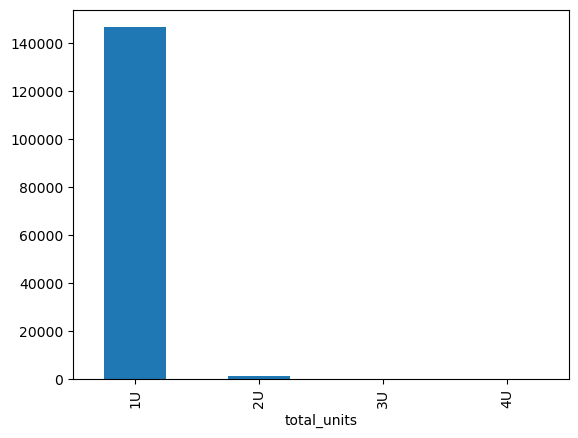

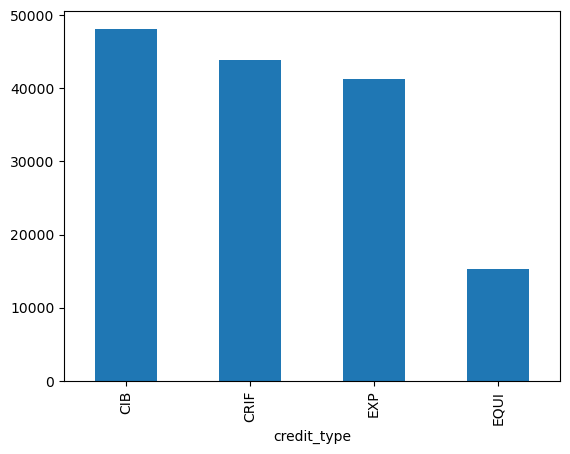

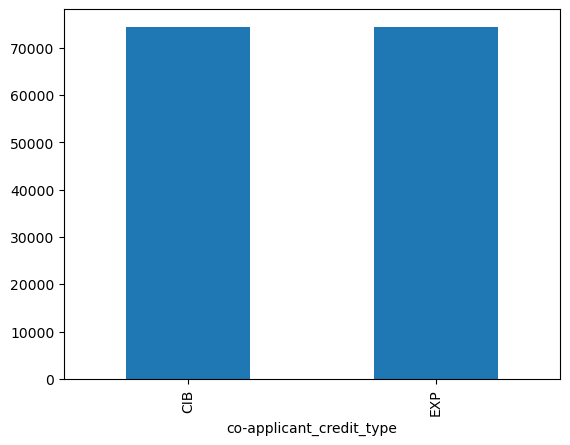

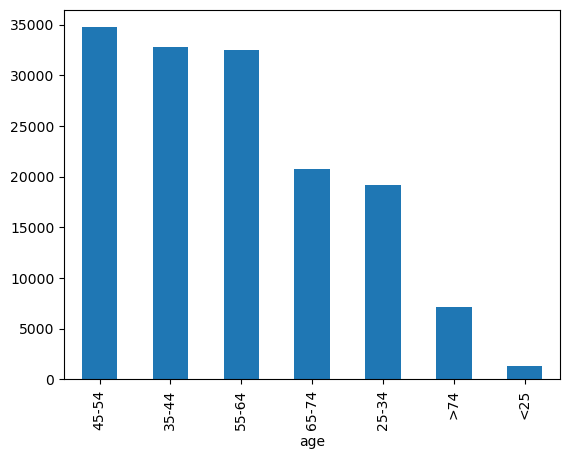

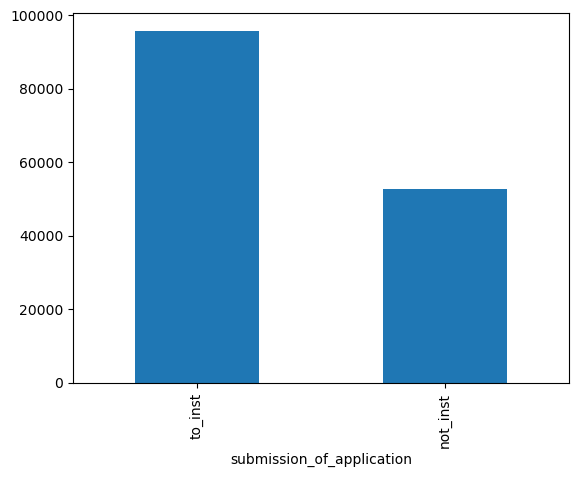

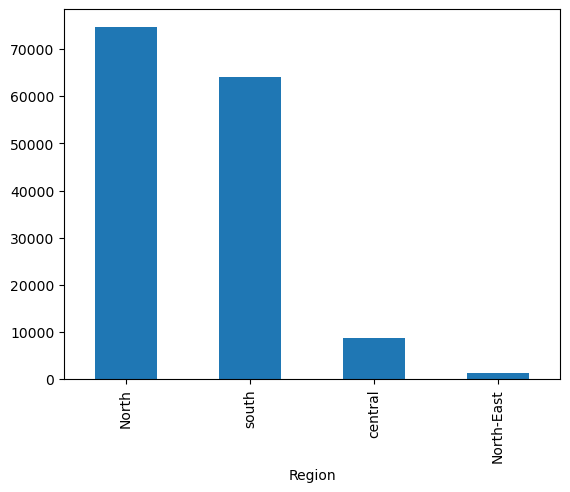

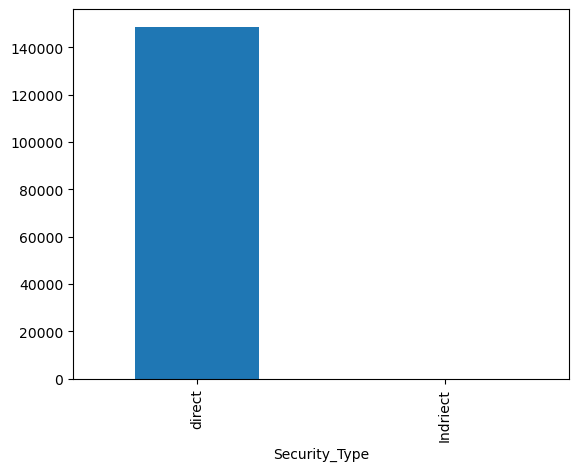

In [29]:
for column in loan_df.select_dtypes("object").columns:
    loan_df[column].value_counts(normalize=False).plot.bar()
    plt.show()

## Feature Engineering

In [30]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [31]:
(loan_df[["Credit_Score", "loan_amount"]] 
 - loan_df[["Credit_Score", "loan_amount"]].mean()) / loan_df[["Credit_Score", "loan_amount"]].std()

,Credit_Score,loan_amount
0,0.502356,-1.166976
1,-1.275409,-0.677604
2,1.158230,0.409888
3,-0.973362,0.681761
4,-0.843913,1.986752
...,...,...
148665,-0.352007,0.573012
148666,-1.128700,1.388631
148667,0.019080,0.627387
148668,0.321127,-0.731979


Ši formulė atlieka **duomenų standartizavimą (Z-score scaling)**.

Kiekvienai reikšmei:
- atimamas **stulpelio vidurkis (mean)**
- padalinama iš **stulpelio standartinio nuokrypio (std)**

Rezultatas:
- kintamųjų **vidurkis tampa 0**
- **standartinis nuokrypis tampa 1**

Tai dažnai daroma prieš **mašininio mokymosi modelius**, kad skirtingų skalių kintamieji būtų **palyginami**.

In [80]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

std.fit_transform(loan_df[["Credit_Score", "loan_amount"]])

array([[ 0.50235739, -1.16697989],
       [-1.27541323, -0.6776066 ],
       [ 1.15823392,  0.40988958],
       ...,
       [ 0.01907994,  0.62738881],
       [ 0.32112834, -0.73198141],
       [ 1.12371411,  0.40988958]])

In [33]:
loan_df["total_units"].value_counts()

total_units
1U    146480
2U      1477
3U       393
4U       320
Name: count, dtype: int64

<Axes: xlabel='total_units', ylabel='Status'>

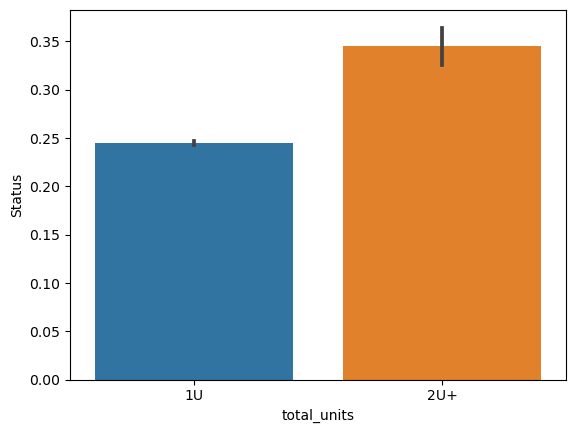

In [81]:
sns.barplot(loan_df, x="total_units", y="Status")

In [35]:
loan_df = loan_df.assign(
    total_units = loan_df["total_units"].map({
        "1U": "1U",
        "2U": "2U+",
        "3U": "2U+",
        "4U": "2U+"}),
    loan_amt_v_income = loan_df["loan_amount"]/loan_df["income"]
)

loan_df[["total_units", "loan_amt_v_income"]].head()

,total_units,loan_amt_v_income
0,1U,66.954023
1,1U,41.465863
2,1U,42.879747
3,1U,38.425926
4,1U,66.714559


<Axes: xlabel='total_units', ylabel='Status'>

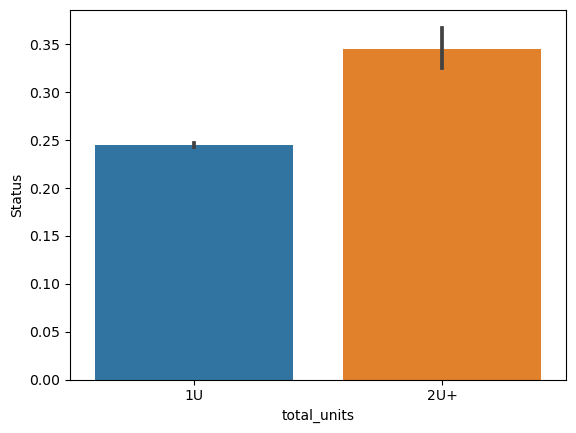

In [82]:
sns.barplot(loan_df, x="total_units", y="Status")

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='loan_amt_v_income', ylabel='Count'>

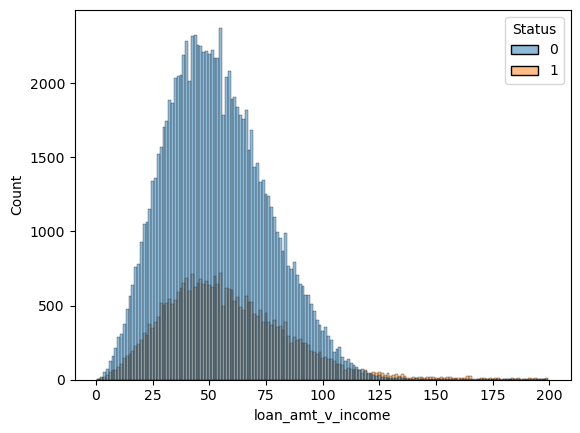

In [83]:
sns.histplot(
    loan_df.query("loan_amt_v_income < 200"), 
    hue="Status",
    x="loan_amt_v_income"
)

In [84]:
def add_deviation_feature(X, feature, category):
    
    # temp groupby object
    category_gb = X.groupby(category)[feature]
    
    # create columns of category means and standard deviations
    category_mean = category_gb.transform(lambda x: x.mean())
    category_std = category_gb.transform(lambda x: x.std())
    
    # compute stds from category mean for each feature value,
    # add to X as new feature
    deviation_feature = (X[feature] - category_mean) / category_std 
    X[feature + '_Dev_' + category] = deviation_feature


add_deviation_feature(loan_df, 'income', 'Region')

loan_df[["income", "Region", "income_Dev_Region"]].sample(20).sort_values("income")

,income,Region,income_Dev_Region
8920,2460.0,North,-0.675584
123881,2940.0,North,-0.603962
52475,3000.0,North,-0.595010
69864,3900.0,south,-0.479248
103564,4320.0,south,-0.414414
115951,5040.0,North,-0.290616
70347,5400.0,North,-0.236900
122022,6120.0,south,-0.136552
763,6300.0,North,-0.102609
125174,7140.0,North,0.022730


Funkcija **add_deviation_feature()** sukuria naują kintamąjį, kuris parodo, **kiek kiekviena reikšmė skiriasi nuo savo kategorijos vidurkio**.

Veikimo principas:
- Duomenys sugrupuojami pagal **kategoriją** (pvz., Region).
- Apskaičiuojamas kiekvienos kategorijos **vidurkis** ir **standartinis nuokrypis**.
- Kiekviena reikšmė paverčiama **standartizuotu nuokrypiu nuo kategorijos vidurkio**.

Formulė:
(feature reikšmė − kategorijos vidurkis) / kategorijos standartinis nuokrypis

Rezultatas įrašomas kaip naujas stulpelis, pvz. **income_Dev_Region**, kuris parodo, ar pajamos yra **aukštesnės ar žemesnės nei to regiono vidurkis**.

## Data Prep

In [85]:
# Drop useless/unpromising columns

prep_loan_df = loan_df.drop([
    "year", 
     "ID", 
     "open_credit", 
    "construction_type", 
    "Security_Type", 
    "Secured_by"], 
    axis=1
)

prep_loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 145326 non-null  object 
 1   Gender                     148670 non-null  object 
 2   approv_in_adv              147762 non-null  object 
 3   loan_type                  148670 non-null  object 
 4   loan_purpose               148536 non-null  object 
 5   Credit_Worthiness          148670 non-null  object 
 6   business_or_commercial     148670 non-null  object 
 7   loan_amount                148670 non-null  int64  
 8   rate_of_interest           112231 non-null  float64
 9   Interest_rate_spread       112031 non-null  float64
 10  Upfront_charges            109028 non-null  float64
 11  term                       148629 non-null  float64
 12  Neg_ammortization          148549 non-null  object 
 13  interest_only              14

In [86]:
# data splitting

from sklearn.model_selection import train_test_split

X = pd.get_dummies(prep_loan_df[["loan_limit", "Gender", "loan_amount"]], drop_first=True)
y = prep_loan_df["Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=2023)

print(f"Training Size: {X_train.shape[0]}, Test Size: {X_test.shape[0]}")

Training Size: 118936, Test Size: 29734


In [44]:
# feature scaling

from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)